# PlatoSim configuration parameters

### Setup notebook

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

### Imports

In [2]:
# Built-in
import math

# PlatoSim standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as patches
import scipy
import scipy.constants as c
from astropy.modeling import models, fitting
from decimal import Decimal

# PlatoSim functions
import platosim.referenceFrames as rf
from platosim.matplotlibrc import setup_paper
setup_paper()

### Global functions

In [3]:
def sci_str(dec):
    dec = Decimal(str(dec))
    return ('{:.' + str(len(dec.normalize().as_tuple().digits) - 1) + 'E}').format(dec)

### Applicable documents

- AD-1: PLATO Mission Requirements Document, D. Agnolon
- AD-2: PLATO 01 R BOL, data package v1.7 (normal camera, beginning of life, required), Anko Börner 
- AD-3: PLATO 02 R BOL, data package v1.7 (normal camera, end of life, required), Anko Börner
- AD-5: PLATO 80 FCamB R EOL, data package v1.7 (fast camera, blue, end of life, required), Anko Börner 
- AD-7: PLATO 81 FCamR R EOL, data package v1.7 (fast camera, red, end of life, required), Anko Börner
- AD-8: PLATO-DLR-PL-TN-003 Reference Photon Flux
- AD-9: PLATO-DLR-PL-RP-001 Instrument Noise Budget
- AD-10: PLATO-INAF-PL-RP-001, Telescope Optical Units Performance Analysis report, v2
- AD-11: PLATO-DLR-PL-RP-004, Simulations nad Performance Estimations, v1
- AD-12: PLATO-ESTEC-PL-RS-003, PLATO CCD requirements
- AD-13: Modelling CTI in PLATO-like images, T. Prod’homme, T. Oosterbroek
- AD-14: PLATO-OHV-PL-LI-0009, PLATO Instrument Coordinate Systems
- AD-15: PLATO-KUL-PL-TN-0001, PlatoSim Reference Frames
- AD-16: PLATO-OHB-PL-RS-005, N FEE User Requirements Document, v2
- AD-17: CTI measurements, modelling, requirements, Anko Börner
- AD-18: PLATO-DLR-PL-TN-016: Geometric Camera Model for PLATO TOU
- AD-19: Photometry impacts of Brighter-Fatter Effect (BFE) and CCD  diffusion, Réza Samadi
- AD-20: PLATO-KUL-PL-TN-0003: PLATO FEE readout modes for AIV, Pierre Royer & Ann Baeke

### Reference documents

- RD-1: An analytical model of radiation-induced Charge Transfer Inefficiency for CCD detectors, Short, A. et al., MNRAS 420, 3078-3085, 2013
- RD-2: Evidence for self-interaction of charge distribution in charge-coupled devices, Guyonnet, A. et al. A & A, 575, A41, 2015


---
## Constant parameters 
---

## Mission duration
Req. MRD-SC-009 in [AD-1]

In [28]:
# Mission duration [years]
missionDuration = 6.5
print("Mission duration:", missionDuration, "years")

Mission duration: 6.5 years


## Cycle time
Req. 300 in [AD-2] - [AD-7]

In [29]:
cycleTimeNormal = 25     # Cycle time for the normal cameras [s]
cycleTimeFast   = 2.5    # Cycle time for the fast cameras [s]
print("Cycle time (normal cameras):", cycleTimeNormal, "s")
print("Cycle time (fast   cameras):", cycleTimeFast, "s")

Cycle time (normal cameras): 25 s
Cycle time (fast   cameras): 2.5 s


## Light collecting area
* Light collecting area: req. 410 in [AD-2] - [AD-7]
* Effective pupil diameter: req. 420 in [AD-2] - [AD-7]

In [30]:
# Light collecting area [cm^2]
lightCollectingArea = 113.1
print("Light collecting area:", lightCollectingArea, "cm^2")

# Effective pupil diameter [cm]
effectivePupilSize = 12
print(f"Validate result above: {c.pi * pow(12 / 2, 2):.3f} cm^2")

Light collecting area: 113.1 cm^2
Validate result above: 113.097 cm^2


## Pixel size
Req. 630 in [AD-2] - [AD-7]

In [31]:
pixelSize = 18  # Pixel size [µm  / pixel]

print("Pixel size:", pixelSize, "micron / pixel")

Pixel size: 18 micron / pixel


## Plate scale
* Pixel size: see above
* Plate scale [arcsec / pixel]: req. 440 in [AD-2] - [AD-7]

In [32]:
# Plate scale [arcsec/pixel -> arcsec / µm]
plateScaleArcsec = 15
plateScale =  plateScaleArcsec / pixelSize 
print(f"Plate scale: {plateScale:.3f} arcsec / micron")

Plate scale: 0.833 arcsec / micron


## Focal length
Req. 420 in [AD-2] - [AD-8]

The focal length, expressed in m, can be calculated as:

$$\rm{focal\,length [m]} = \frac{\rm pixel\,size}{\tan{\left( \frac{\rm plate\,scale}{2} \right)}}.$$

Alternatively, expressed in pixels:

$$\rm{focal\,length [pixels]} = \frac{1}{\tan{(\rm plate\,scale)}}$$

In [33]:
pixelSizeMeter = pixelSize * c.micro              # Pixel size [µm] -> [m]
plateScaleRadians = plateScaleArcsec * c.arcsec   # Plate scale [arcsec] -> [radians]

focalLength = pixelSizeMeter / (math.tan(plateScaleRadians))    # Focal length [m]
focalLengthPixels = math.ceil(1 / math.tan(plateScaleRadians))  # Focal length [pixels]

print("Focal length:", focalLength, "m")
print("Focal length:", focalLengthPixels, "pixels")

Focal length: 0.24751776706018333 m
Focal length: 13751 pixels


## CCD Positions
* Number of rows: req. 610 in [AD-2] - AD-7
* Number of columns: req. 620 in [AD-2] - AD-7
* Butting distance: req. req. 285 in [AD-2] - [AD-7]

In [34]:
numRows = 4510
numColumns = 4510

# Butting distance [mm]
buttingDistance = 2.6
halfButtingDistance = buttingDistance / 2.0

deltaX = halfButtingDistance
deltaY = halfButtingDistance + numRows * pixelSize * (c.micro / c.milli)
rotationAngle = {"1": 180, "2": 270, "3": 0, "4": 90, "1F": 180, "2F": 270, "3F": 0, "4F": 90}

In [35]:
def printCCD(ccd):    
    print("CCD", ccd, "has", numRows, "x", numColumns, "pixels, offset (" + str(deltaX) + 
          " mm,", str(deltaY) + " mm) and a rotation angle of", str(rotationAngle[ccd]) + "°")

In [36]:
print("CCDs for the N-CAMs:\n")
for ccd in ["1", "2", "3", "4"]:   
    printCCD(ccd)

CCDs for the N-CAMs:

CCD 1 has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 180°
CCD 2 has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 270°
CCD 3 has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 0°
CCD 4 has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 90°


In [37]:
print("CCDs for the F-CAMs:\n")
for ccd in ["1F", "2F", "3F", "4F"]:  
    printCCD(ccd) 

CCDs for the F-CAMs:

CCD 1F has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 180°
CCD 2F has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 270°
CCD 3F has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 0°
CCD 4F has 4510 x 4510 pixels, offset (1.3 mm, 82.48 mm) and a rotation angle of 90°


## Wavelength range

* Minimum wavelength: req. 240 in [AD-2] - [AD-7]
* Maximum wavelength: req. 250 in [AD-2] - [AD-7]

In [39]:
minWavelength = 450      # Minimum wavelength [nm]
maxWavelength = 1050     # Maximum wavelength [nm]

print("Wavelength range for simulations:", minWavelength, " -", maxWavelength, "nm")

Wavelength range for simulations: 450  - 1050 nm


## Reference wavelength
Req. 070 in [AD-2] - [AD-7]

In [40]:
# Reference wavelength of Johnson-Counsin V passband [nm]
refWavelength = 550
print("Reference wavelength:", refWavelength, "nm")

Reference wavelength: 550 nm


---
## Light and electron sources
---

### Cosmic hits
Req. 790 in [AD-2] - [AD-9]

In [38]:
# Cosmic hit rate [events / cm^2 / s]
cosmicHitRate = 10
print("Cosmic hit rate:", cosmicHitRate, "events / cm^2 / s")

Cosmic hit rate: 10 events / cm^2 / s


### Reference photon flux

#### Irradiance
Irradiance at magnitude 0 for a G0V star at 6000K: Table 2-1 in [AD-8] and Table 4-1 in [AD-9]

In [41]:
# Wavelengths 400-1100 [nm]
wavelengthIrradiance = np.arange(400, 1150, 50)

# Irradiance [1e5 photons / cm^2 / s]
irradiances = np.array([3.45, 4.20, 4.72, 5.01, 5.11, 5.09, 4.96, 4.77, 4.55, 4.30, 4.04, 3.79, 3.55, 3.31, 3.09])
irradiances *= 1e5

# Integrated over all wavelengths (450 - 1050 nm)
minWavelengthIndex = np.where(wavelengthIrradiance == minWavelength)[0][0]
maxWavelengthIndex = np.where(wavelengthIrradiance == maxWavelength)[0][0] + 1
irradiance = (np.sum(irradiances[minWavelengthIndex + 1:maxWavelengthIndex]) + 
              irradiances[minWavelengthIndex - 1] / 2 + irradiances[maxWavelengthIndex] / 2)

# irradiance = np.sum(irradiances[minWavelengthIndex:maxWavelengthIndex]) * 1e5  # Irradiance [photons / cm^2 / s]
print("Irradiance calculated over wavelength range", 
      wavelengthIrradiance[minWavelengthIndex], "-", 
      wavelengthIrradiance[maxWavelengthIndex], "nm:")
print("Irradiance:", sci_str(irradiance), "photons/cm^2/s")

Irradiance calculated over wavelength range 450 - 1100 nm:
Irradiance: 5.647E+6 photons/cm^2/s


In [42]:
# Wavelengths [nm]
# wvl_FcamB = np.arange(500,  750, 50)  # 500-700 nm
# wvl_FcamR = np.arange(700, 1050, 50)  # 700-1000 nm

# Irradiance [photons / cm^2 / s]
# irradiances_Ncams = np.array([4.20, 4.72, 5.01, 5.11, 5.09, 4.96, 4.77, 4.55, 4.30, 4.04, 3.79, 3.55, 3.31]) * 1e5
# irradiances_FcamB = np.array([4.72, 5.01, 5.11, 5.09]) * 1e5
# irradiances_FcamR = np.array([5.09, 4.96, 4.77, 4.55, 4.30, 4.04, 3.79, 3.55, 3.31]) * 1e5

irradiance_Ncams = np.trapz(irradiances)
irradiance_FcamB = np.trapz(irradiances[minWavelengthIndex:6])
irradiance_FcamR = np.trapz(irradiances[6:maxWavelengthIndex])

# irradiance = np.sum(irradiances[minWavelengthIndex:maxWavelengthIndex]) * 1e5  # Irradiance [photons / cm^2 / s]
print("Irradiance for N-CAM      :", sci_str(irradiance_Ncams), "photons/cm^2/s")
print("Irradiance for F-CAM blue :", sci_str(irradiance_FcamB), "photons/cm^2/s")
print("Irradiance for F-CAM red  :", sci_str(irradiance_FcamR), "photons/cm^2/s")

Irradiance for N-CAM      : 6.067E+6 photons/cm^2/s
Irradiance for F-CAM blue : 1.9485E+6 photons/cm^2/s
Irradiance for F-CAM red  : 2.9135E+6 photons/cm^2/s


<IPython.core.display.Javascript object>


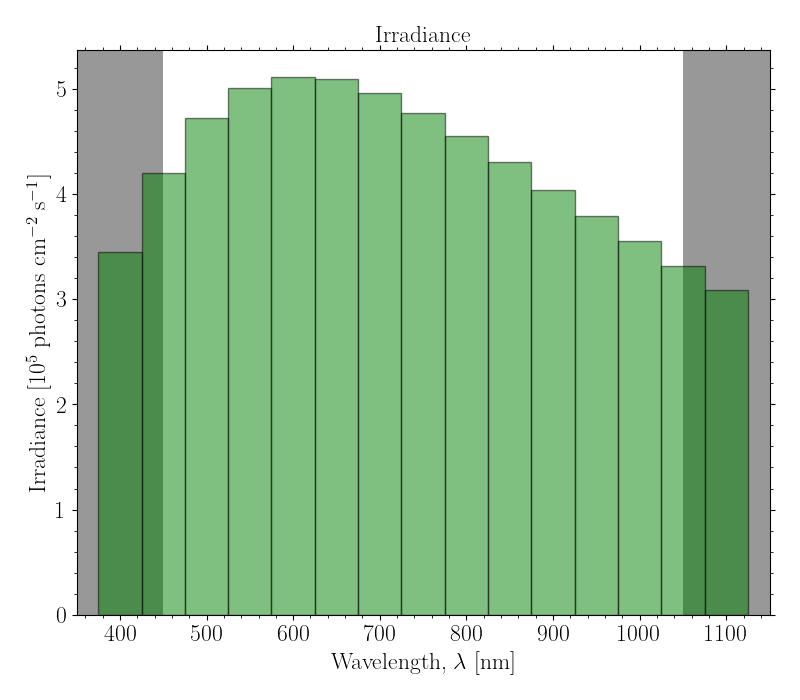

In [43]:
# Plot irradiance histogram for N-CAM
fig = plt.figure(figsize=(8, 7))
# Plots
plt.axvspan(350, minWavelength, facecolor='0.2', alpha=0.5)
plt.axvspan(maxWavelength, 1150, facecolor='0.2', alpha=0.5)
plt.bar(wavelengthIrradiance, irradiances/1e5, width=50, color="g", edgecolor="k", alpha=0.5)
# Labels
plt.title("Irradiance")
plt.xlabel("Wavelength, $\lambda$ [nm]")
plt.ylabel(r'Irradiance [$10^5$ photons cm$^{-2}$ s$^{-1}$]')
# Seetings
plt.xlim([350, 1150])
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


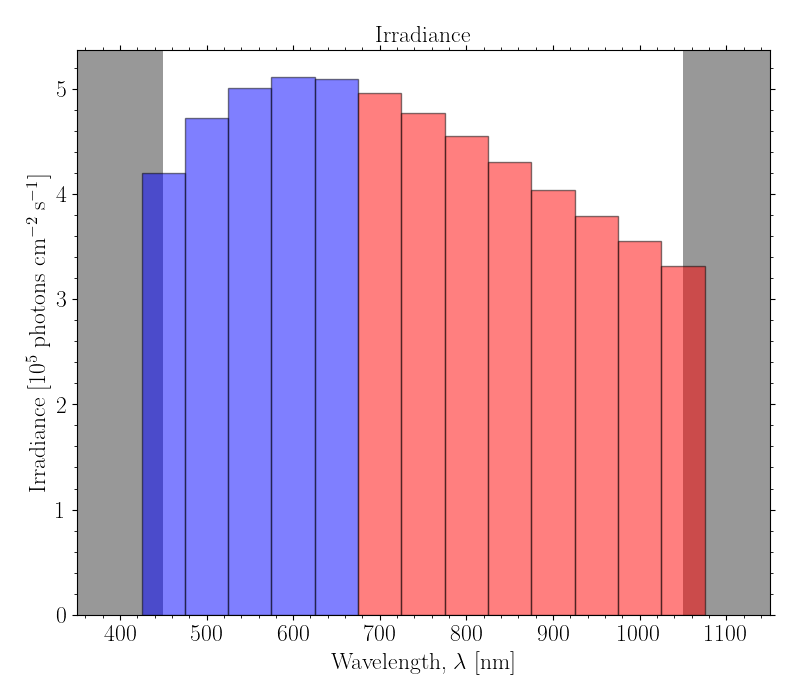

In [44]:
# Plot irradiance histogram for F-CAMs
fig = plt.figure(figsize=(8, 7))
# Plots
plt.axvspan(350, minWavelength, facecolor='0.2', alpha=0.5)
plt.axvspan(maxWavelength, 1150, facecolor='0.2', alpha=0.5)
plt.bar(wavelengthIrradiance[minWavelengthIndex:6], irradiances[minWavelengthIndex:6]/1e5, width=50, color="b", edgecolor="k", alpha=0.5)
plt.bar(wavelengthIrradiance[6:maxWavelengthIndex], irradiances[6:maxWavelengthIndex]/1e5, width=50, color="r", edgecolor="k", alpha=0.5)
# Labels
plt.title("Irradiance")
plt.xlabel("Wavelength, $\lambda$ [nm]")
plt.ylabel(r'Irradiance [$10^5$ photons cm$^{-2}$ s$^{-1}$]')
# Seetings
plt.xlim([350, 1150])
plt.tight_layout()
plt.show()

#### Photon flux
* Reference photometric flux : req. 060 in [AD-2] - [AS-7]
* Reference wavelength: see above

In [68]:
# Reference photometric flux  [W/cm^2/µm -> J/s/m^2/nm]
photometricFlux = 3.6182e-12
photometricFlux *= (pow(c.centi, -2) * (c.nano / c.micron))

# Energy of one photon at the reference wavelength [J]
refWavelength = 550
photonEnergy = c.h * c.c / refWavelength / c.nano

# Photon flux [photons/s/m^2/nm]
photonFlux = photometricFlux / photonEnergy
print("Photon flux in V passband:", sci_str(photonFlux), "photons/s/m^2/nm")

Photon flux in V passband: 1.0017942310575669E+8 photons/s/m^2/nm


In [69]:
# Test of scaling Fluxm0 from V to PLATO passbands
zp_Ncams = 20.77
zp_FcamB = 20.18
zp_FcamR = 19.81
V_P = 0.34

photonFlux_Ncams = 10**(-0.4 * V_P) * photonFlux
photonFlux_FcamB = 10**(-0.4 * (zp_Ncams-zp_FcamB)) * photonFlux_Ncams
photonFlux_FcamR = 10**(-0.4 * (zp_Ncams-zp_FcamR)) * photonFlux_Ncams

print("Photon flux for N-CAM      :", sci_str(photonFlux_Ncams), "photons/s/m^2/nm")
print("Photon flux for F-CAM blue :", sci_str(photonFlux_FcamB), "photons/s/m^2/nm")
print("Photon flux for F-CAM red  :", sci_str(photonFlux_FcamR), "photons/s/m^2/nm")

Photon flux for N-CAM      : 7.324509159344043E+7 photons/s/m^2/nm
Photon flux for F-CAM blue : 4.253814295555959E+7 photons/s/m^2/nm
Photon flux for F-CAM red  : 3.0253702115711115E+7 photons/s/m^2/nm


In [67]:
# Reference photometic flux for N-CAMs [W/cm^2/µm -> J/s/m^2/nm]
photometricFlux_Ncams = (photonEnergy * photonFlux_Ncams) * (c.centi**(-2) * (c.nano / c.micron)) 
photometricFlux_FcamB = (photonEnergy * photonFlux_FcamB) * (c.centi**(-2) * (c.nano / c.micron)) 
photometricFlux_FcamR = (photonEnergy * photonFlux_FcamR) * (c.centi**(-2) * (c.nano / c.micron)) 

print("Reference photometic flux for N-CAM      :", sci_str(photometricFlux_Ncams), "photons/s/m^2/nm")
print("Reference photometic flux for F-CAM blue :", sci_str(photometricFlux_FcamB), "photons/s/m^2/nm")
print("Reference photometic flux for F-CAM red  :", sci_str(photometricFlux_FcamR), "photons/s/m^2/nm")

Reference photometic flux for N-CAM      : 2.645407431859701E-10 photons/s/m^2/nm
Reference photometic flux for F-CAM blue : 1.5363585062705496E-10 photons/s/m^2/nm
Reference photometic flux for F-CAM red  : 1.0926789314758566E-10 photons/s/m^2/nm


---
## Total throughput
---

### Throughput bandwidth

In [20]:
# Throughput bandwidth [nm]
throughputBandwidth_Ncams = (irradiance_Ncams / c.centi**2) / photonFlux
throughputBandwidth_FcamB = (irradiance_FcamB / c.centi**2) / photonFlux_FcamB
throughputBandwidth_FcamR = (irradiance_FcamR / c.centi**2) / photonFlux_FcamR
print(f"Throughput bandwidth for N-CAM     : {throughputBandwidth_Ncams:.2f} nm")
print(f"Throughput bandwidth for F-CAM blue: {throughputBandwidth_FcamB:.2f} nm")
print(f"Throughput bandwidth for F-CAM red : {throughputBandwidth_FcamR:.2f} nm")

Throughput bandwidth for N-CAM     : 605.61 nm
Throughput bandwidth for F-CAM blue: 334.91 nm
Throughput bandwidth for F-CAM red : 704.10 nm


In [21]:
(irradiance / c.centi**2) / 1.00179e8

563.690993122311

### Transmission efficiency (transmissivity of the optics)
Req. 480 in [AD-2] - [AD-7]:
* optics_transmission_1.2pc_bol_cutoff_19-03-31.txt
* optics_transmission_1.2pc_eol_cutoff_19-03-31.txt

In [24]:
# Transmission curves from [450-1050 nm]
wvl = np.arange(450, 1100, 50) 
TE_BOL = np.array([0.7330, 0.7651, 0.7972, 0.8048, 0.8107, 0.8183, 0.8243, 0.8284, 0.8301, 0.8319, 0.8327, 0.8344, 0.8361])
TE_EOL = np.array([0.7039, 0.7379, 0.7719, 0.7835, 0.7918, 0.8018, 0.8076, 0.8125, 0.8142, 0.8158, 0.8175, 0.8183, 0.8191])

# Transform into range [500-1000 nm]
wvl, TE_BOL, TE_EOL = wvl[1:-1], TE_BOL[1:-1], TE_EOL[1:-1]

# As simulated transmission values for F-CAMs
TE_fil_FCAM_blue = 0.986
TE_fil_FCAM_red  = 0.989

<IPython.core.display.Javascript object>


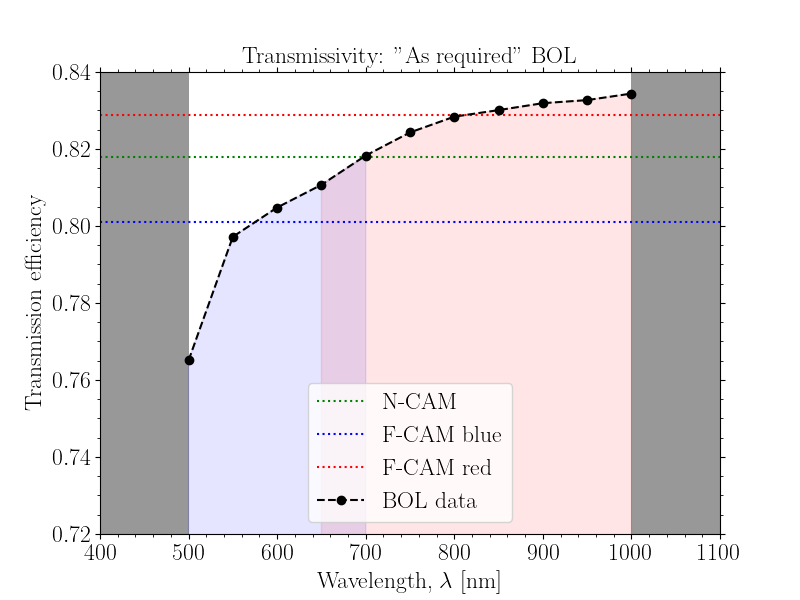

Wavelenght range : 500 - 1000 nm:
BOL Transmissivity of N-CAM     : 0.8178
BOL Transmissivity of F-CAM blue: 0.7899
BOL Transmissivity of F-CAM red : 0.8198


In [25]:
# Mean transmission
TE_BOL_NCAM      = np.trapz(TE_BOL     / (len(TE_BOL)     - 1))
TE_BOL_FCAM_blue = np.trapz(TE_BOL[:5] / (len(TE_BOL[:5]) - 1))
TE_BOL_FCAM_red  = np.trapz(TE_BOL[4:] / (len(TE_BOL[4:]) - 1))

plt.figure(figsize=(8,6))
# Plot
plt.axvspan(400, wvl[0],   facecolor='0.2', alpha=0.5)
plt.axvspan(wvl[-1], 1100, facecolor='0.2', alpha=0.5)
plt.fill_between(wvl[:5], TE_BOL[:5], color='blue', alpha=.1)
plt.fill_between(wvl[3:], TE_BOL[3:], color='red',  alpha=.1)
plt.axhline(y=TE_BOL_NCAM,      color='g', linestyle=':', label = "N-CAM")
plt.axhline(y=TE_BOL_FCAM_blue, color='b', linestyle=':', label = "F-CAM blue")
plt.axhline(y=TE_BOL_FCAM_red,  color='r', linestyle=':', label = "F-CAM red")
plt.plot(wvl, TE_BOL, "ko--", label = "BOL data")
# Labels
plt.title('Transmissivity: "As required" BOL')
plt.xlabel(r"Wavelength, $\lambda$ [nm]")
plt.ylabel("Transmission efficiency")
# Setting
plt.legend()
plt.xlim(400, 1100)
plt.ylim(0.72, 0.84)
plt.show()

# Print results
# Note that transmissivity in PlatoSim is including the filter
print(f"Wavelenght range : {wvl[0]} - {wvl[-1]} nm:")
print(f"BOL Transmissivity of N-CAM     : {TE_BOL_NCAM:.4f}")
print(f"BOL Transmissivity of F-CAM blue: {TE_BOL_FCAM_blue * TE_fil_FCAM_blue:.4f}")
print(f"BOL Transmissivity of F-CAM red : {TE_BOL_FCAM_red  * TE_fil_FCAM_red:.4f}")


<IPython.core.display.Javascript object>


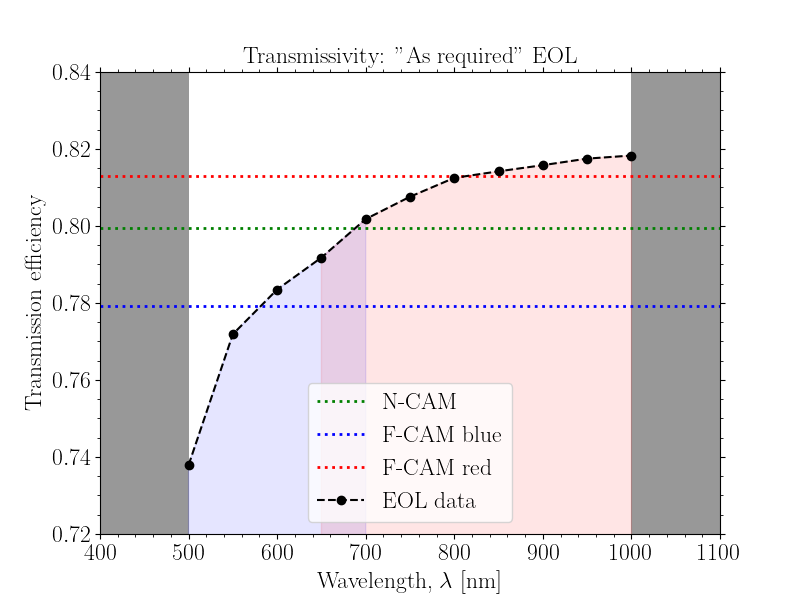

Wavelenght range : 500 - 1000 nm:
EOL Transmissivity of N-CAM     : 0.7995
EOL Transmissivity of F-CAM blue: 0.7684
EOL Transmissivity of F-CAM red : 0.8040


In [26]:
# Mean transmission
TE_EOL_NCAM      = np.trapz(TE_EOL     / (len(TE_EOL)     - 1))
TE_EOL_FCAM_blue = np.trapz(TE_EOL[:5] / (len(TE_EOL[:5]) - 1))
TE_EOL_FCAM_red  = np.trapz(TE_EOL[4:] / (len(TE_EOL[4:]) - 1))

plt.figure(figsize=(8,6))
# Plot
plt.axvspan(400, wvl[0],   facecolor='0.2', alpha=0.5)
plt.axvspan(wvl[-1], 1100, facecolor='0.2', alpha=0.5)
plt.fill_between(wvl[:5], TE_EOL[:5], color='blue', alpha=.1)
plt.fill_between(wvl[3:], TE_EOL[3:], color='red',  alpha=.1)
plt.axhline(y=TE_EOL_NCAM,      color='g', linestyle=':', linewidth=2, label = "N-CAM")
plt.axhline(y=TE_EOL_FCAM_blue, color='b', linestyle=':', linewidth=2, label = "F-CAM blue")
plt.axhline(y=TE_EOL_FCAM_red,  color='r', linestyle=':', linewidth=2, label = "F-CAM red")
plt.plot(wvl, TE_EOL, "ko--", label = "EOL data")
# Labels
plt.title('Transmissivity: "As required" EOL')
plt.xlabel(r"Wavelength, $\lambda$ [nm]")
plt.ylabel("Transmission efficiency")
# Setting
plt.legend()
plt.xlim(400, 1100)
plt.ylim(0.72, 0.84)
plt.show()

# Print results
print(f"Wavelenght range : {wvl[0]} - {wvl[-1]} nm:")
print(f"EOL Transmissivity of N-CAM     : {TE_EOL_NCAM:.4f}")
print(f"EOL Transmissivity of F-CAM blue: {TE_EOL_FCAM_blue * TE_fil_FCAM_blue:.4f}")
print(f"EOL Transmissivity of F-CAM red : {TE_EOL_FCAM_red  * TE_fil_FCAM_red:.4f}")


Data from: Table 1 from PTO-EST-PL-REP-0952 i.1.1

Transmissivity wavelenght range : 500 - 1000 nm:
Transmissivity N-CAM expected (BOL): 0.823
Transmissivity N-CAM required (BOL): 0.765


<IPython.core.display.Javascript object>


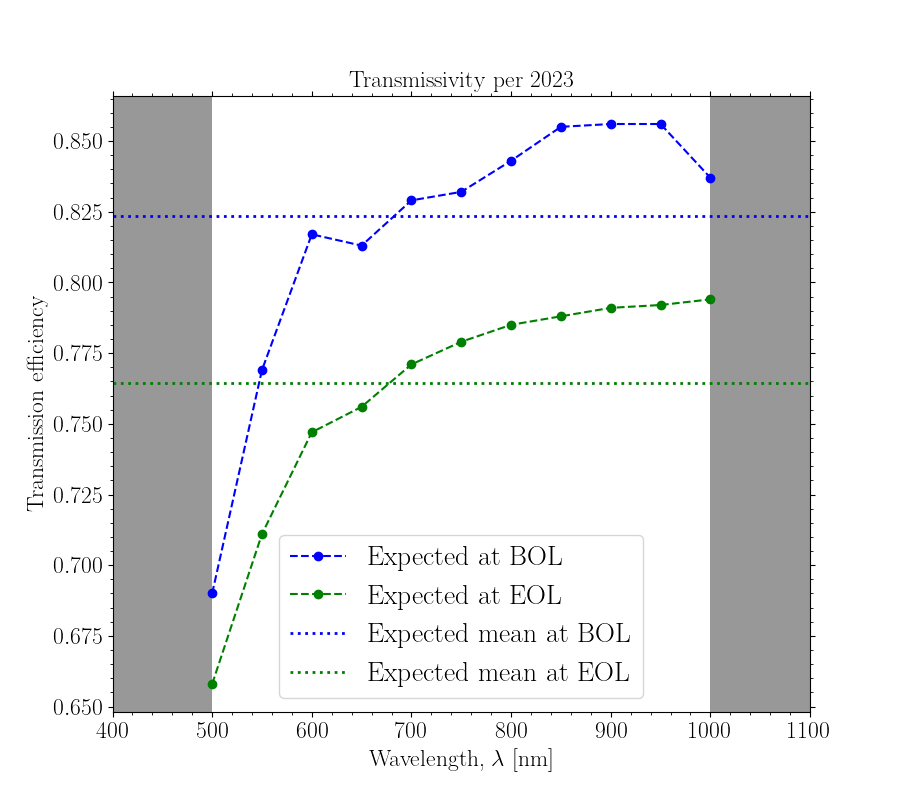

In [27]:
wvl = np.arange(500, 1050, 50)
MOC = np.array([0.880, 0.914, 0.953, 0.959, 0.969, 0.972, 0.974, 0.976, 0.978, 0.978, 0.978])
PAC = np.ones_like(MOC) * 0.98
TE_BOL_clean    = np.array([0.800, 0.858, 0.875, 0.864, 0.874, 0.873, 0.883, 0.893, 0.893, 0.893, 0.873])
TE_BOL_expected = np.array([0.690, 0.769, 0.817, 0.813, 0.829, 0.832, 0.843, 0.855, 0.856, 0.856, 0.837])
TE_BOL_required = np.array([0.658, 0.711, 0.747, 0.756, 0.771, 0.779, 0.785, 0.788, 0.791, 0.792, 0.794])

# Mean transmission
TE_BOL_expected_mean = np.trapz(TE_BOL_expected / (len(wvl) - 1))
TE_BOL_required_mean = np.trapz(TE_BOL_required / (len(wvl) - 1))

# Print results
print(f"Transmissivity wavelenght range : {wvl[0]} - {wvl[-1]} nm:")
print(f"Transmissivity N-CAM expected (BOL): {TE_BOL_expected_mean:.3f}")
print(f"Transmissivity N-CAM required (BOL): {TE_BOL_required_mean:.3f}")

# Plot results
plt.figure(figsize=(9,8))
plt.plot(wvl, TE_BOL_expected, "bo--", label = "Expected at BOL")
plt.plot(wvl, TE_BOL_required, "go--", label = "Expected at EOL")
plt.axhline(y=TE_BOL_expected_mean, color='b', linestyle=':', linewidth=2, label = "Expected mean at BOL")
plt.axhline(y=TE_BOL_required_mean, color='g', linestyle=':', linewidth=2, label = "Expected mean at EOL")
plt.axvspan(350, wvl[0],   facecolor='0.2', alpha=0.5)
plt.axvspan(wvl[-1], 1150, facecolor='0.2', alpha=0.5)
# Labels
plt.title("Transmissivity per 2023")
plt.xlabel(r"Wavelength, $\lambda$ [nm]")
plt.ylabel("Transmission efficiency")
plt.legend(prop={'size': 20})
# Setting
plt.xlim([400, 1100])
plt.show()

### Quantum efficiency

"As required": Req. 650 in [AD-2] - [AD-7]: ccd_qe_min_bol_19-03-31.txt 

Wavelength range 600 - 1000 nm:
As required QE N-CAM     : 0.6537
As required QE F-CAM blue: 0.8070
As required QE F-CAM red : 0.4923


<IPython.core.display.Javascript object>


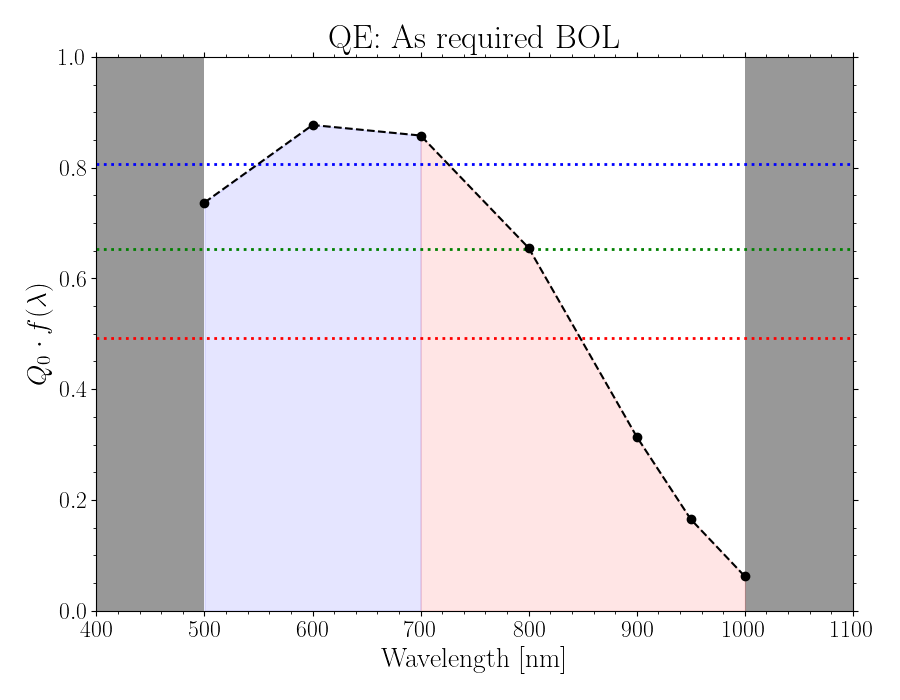

In [46]:
wl = np.array([  400,   450,   500,   600,   700,   800,   900,   950,  1000])
QE = np.array([0.375, 0.575, 0.737, 0.877, 0.858, 0.655, 0.314, 0.165, 0.062])
wl, QE = wl[2:], QE[2:]

QE_BOL_required_NCAM      = np.trapz(QE      / (len(wl[1:])  - 1))
QE_BOL_required_FCAM_blue = np.trapz(QE[:-5] / (len(wl[:-5]) - 1))
QE_BOL_required_FCAM_red  = np.trapz(QE[-6:] / (len(wl[-6:]) - 1))

print(f"Wavelength range {wl[1]} - {wl[-1]} nm:")
print(f"As required QE N-CAM     : {QE_BOL_required_NCAM:.4f}")
print(f"As required QE F-CAM blue: {QE_BOL_required_FCAM_blue:.4f}")
print(f"As required QE F-CAM red : {QE_BOL_required_FCAM_red:.4f}")

fig = plt.figure(figsize=(9,7))
plt.axvspan(350, wl[0], facecolor='0.2', alpha=0.5)
plt.axvspan(wl[-1], 1150, facecolor='0.2', alpha=0.5)
plt.fill_between(wl[:3], QE[:3], color='blue', alpha=.1)
plt.fill_between(wl[2:], QE[2:], color='red',  alpha=.1)
plt.axhline(y=QE_BOL_required_NCAM,      color='g', linestyle=':', linewidth=2, label = "N-CAM")
plt.axhline(y=QE_BOL_required_FCAM_blue, color='b', linestyle=':', linewidth=2, label = "F-CAM blue")
plt.axhline(y=QE_BOL_required_FCAM_red,  color='r', linestyle=':', linewidth=2, label = "F-CAM red")
plt.plot(wl, QE, 'ko--')
# Axes
plt.title("QE: As required BOL", fontsize = 24)
plt.xlabel("Wavelength [nm]", fontsize = 20)
plt.ylabel(r'$Q_0 \cdot f(\lambda )$', fontsize = 20)
plt.xlim(400, 1100)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [46]:
# QE_NCAM = (QE[1] + QE[2]) / 2 * (wl[2] - wl[1])
# QE_NCAM += np.trapz(QE[2:-2]) / (len(QE[2:-2]) - 1) * (wl[-3] - wl[2])
# QE_NCAM += np.trapz(QE[-3:])  / (len(QE[-3:]) - 1)  * (wl[-1] - wl[-3])
# QE_NCAM /= (wl[-1] - wl[1])

# refAngleQE = 45     # Reference angle [°]
# refValueQE = 0.925  # Value of the angle dependency of the QE at the reference angle

Angle dependency: req. 660 in [AD-2] - [AD-7]

In [48]:
expectedEfficiencyAngleDependencyQE = 1.01
print("Expected efficiency caused by the angle dependence of QE:", expectedEfficiencyAngleDependencyQE)

Expected efficiency caused by the angle dependence of QE: 1.01


### Overall Relative Transmissivity
* Natural vignetting (view factor)
* Mechanical vignetting (undersized mask at entrance pupil)
* Glass absorption + Anti-reflective coating

In [52]:
# Circumference of circle: 360° = 2πr
r = 360 / (2 * math.pi)

# Area of spherical cap: A = 2πr² (1 - cosθ) = 1112 deg² with fovDegrees = θ
fovDegrees = math.degrees(math.acos(-1111 / (2 * math.pi * pow(r, 2)) + 1))
print(fovDegrees)

# fovDegrees = 18.8875
fovPixels = fovDegrees / plateScaleArcsec * c.degree / c.arcsec

18.890827981346373


<IPython.core.display.Javascript object>


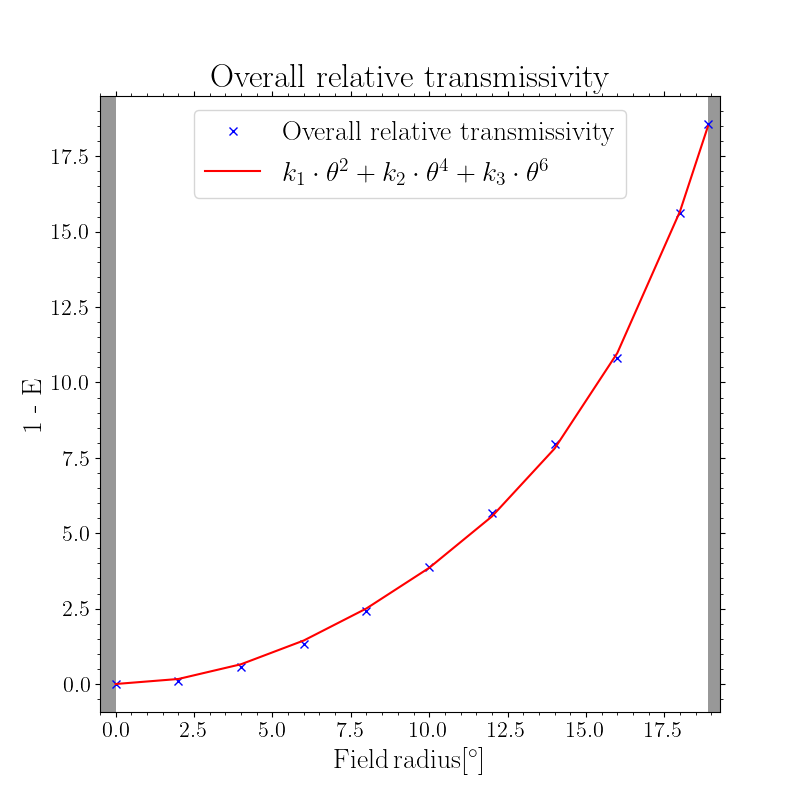

In [54]:
fieldAngles = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 18.89])
relativeTransmissivity = np.array([0, 0.114510078, 0.574988868, 1.319410989, 2.415817227, 
                                   3.867999225, 5.681706313, 7.955807362, 10.82635927, 
                                   15.60670703, 18.57055481])

coefficients = [4.18e-2, -5.65e-5, 2.37e-7]
modelRelativeTransmissivity = coefficients[0] * np.power(fieldAngles, 2) + coefficients[1] * np.power(fieldAngles, 4) + coefficients[2] * np.power(fieldAngles, 6)

plt.figure(figsize=(8,8))
# plt.subplot(221)

plt.plot(fieldAngles, relativeTransmissivity, "bx", label = "Overall relative transmissivity")
plt.plot(fieldAngles, modelRelativeTransmissivity, "r", label = "$k_1 \cdot \\theta^2 + k_2 \cdot \\theta^4 + k_3 \cdot \\theta^6$")

plt.legend(prop={'size': 20})
plt.xlabel(r'$\rm{Field\,radius} [^{\circ}]$', fontsize = 20)
plt.ylabel("1 - E", fontsize = 20)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.title("Overall relative transmissivity", fontsize = 24)
plt.xlim([-0.5, 18.7765+0.5])

plt.axvspan(-1, 0, facecolor='0.2', alpha=0.5)
plt.axvspan(fovDegrees, 20, facecolor='0.2', alpha=0.5)

plt.show()

In [55]:
efficiencyRelativeTransmissivity = np.zeros((numRows, numColumns))
expectedEfficiencyRelativeTransmissivity = 0
numPixelsInFOV = 0

for row in range(numRows):
    yFP = row * pixelSize * c.micro / c.milli + halfButtingDistance
    
    for column in range(numColumns):
        xFP = column * pixelSize * c.micro / c.milli + halfButtingDistance
        angularDistance = math.degrees(rf.gnomonicRadialDistanceFromOpticalAxis(xFP, yFP, focalLength / c.milli))# [degrees]
        
        if angularDistance <= fovDegrees:
            g = (coefficients[0] * math.pow(angularDistance, 2) + 
                 coefficients[1] * math.pow(angularDistance, 4) + 
                 coefficients[2] * math.pow(angularDistance, 6)) / 100.0
            efficiencyRelativeTransmissivity[row][column] = 1 - g
            expectedEfficiencyRelativeTransmissivity += g
            numPixelsInFOV += 1

expectedEfficiencyRelativeTransmissivity /= numPixelsInFOV
print("Expected efficiency caused by overall relative transmissivity:", 1 - expectedEfficiencyRelativeTransmissivity)

Expected efficiency caused by overall relative transmissivity: 0.9201876472028352


<IPython.core.display.Javascript object>


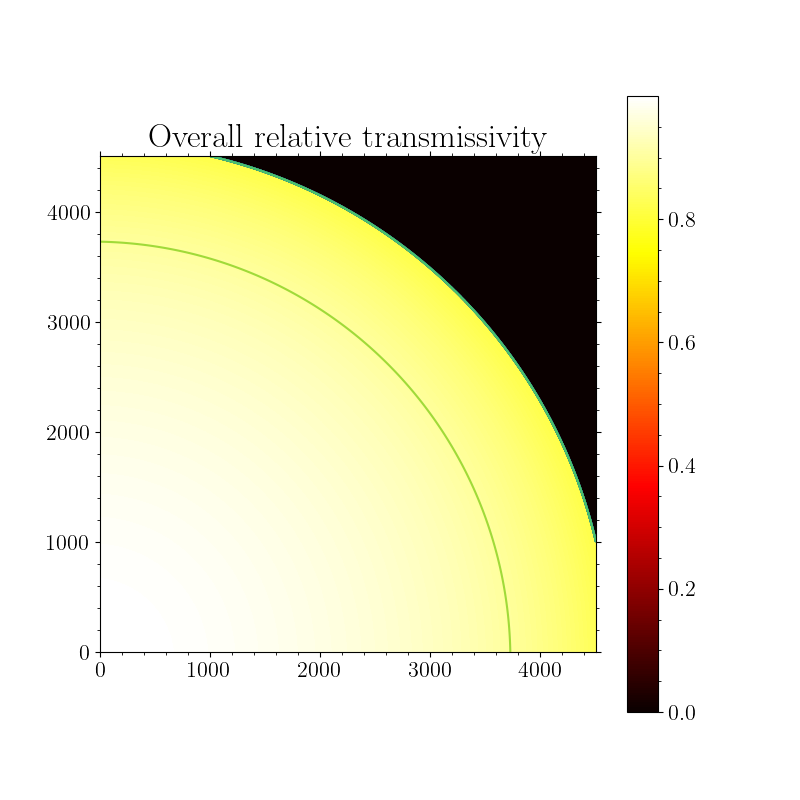

In [56]:
fig,ax = plt.subplots(figsize=(8,8))
plt.imshow(efficiencyRelativeTransmissivity, cmap=cm.hot, interpolation="nearest")
plt.gca().invert_yaxis()
cbar = plt.colorbar()
plt.contour(efficiencyRelativeTransmissivity)
plt.title("Overall relative transmissivity", fontsize = 24)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
cbar.ax.tick_params(labelsize = 16) 
plt.show()

### Polarisation
* Expected efficiency: req. 530 in [AD-2] - [AD-7]

In [58]:
expectedEfficiencyPolarization = 0.989

#refAnglePolarization = 18.8875    # Reference angle [°]
#refValuePolarization = 0.978      # Reference value

print("Expected efficiency caused by polarisation:", expectedEfficiencyPolarization)
#print("Reference for polarisation:", str(refAnglePolarization) + "°")
#print("Efficiency caused by polarisation at the reference angle:", refValuePolarization)

Expected efficiency caused by polarisation: 0.989


### Contamination
* Particulate contamination: req. 500 in [AD-2] - [AD-7]
* Molecular contamination:req. 510 in [AD-2] - [AD-7]

In [59]:
expectedEfficiencyParticulateContamination = 0.972
expectedEfficiencyMolecularContamination = 0.9573

print("Expected efficiency caused by particulate contamination:", expectedEfficiencyParticulateContamination)
print("Expected efficiency caused by molecular contamination:", expectedEfficiencyMolecularContamination)

Expected efficiency caused by particulate contamination: 0.972
Expected efficiency caused by molecular contamination: 0.9573


---
## Focal plane positions
---

### Field distortion

* Distorted ("real") and undistorted ("paraxial") pixel coordinates: PLATO_Field_Distortion.txt (Demetrio)
* Distortion model: Sect. 3.1 in [AD-18]
* Distortion at the edge of the FOV: req. 445 in [AD-2] - [AD-7]
* Size of the FOV: req 432 in [AD-2] - [AD-7]

In [36]:
focalLengthMm = focalLength / c.milli

In [37]:
# Circumference of circle: 360° = 2πr

r = 360 / (2 * math.pi)

# Area of spherical cap: A = 2πr² (1 - cosθ) = 1112 deg² with fovDegrees = θ

fovDegrees = math.degrees(math.acos(-1111 / (2 * math.pi * pow(r, 2)) + 1))
print(fovDegrees)

# fovDegrees = 18.8875
fovPixels = fovDegrees / plateScaleArcsec * c.degree / c.arcsec

18.890827981346376


In [38]:
# Read the distortion file

xDeg, yDeg, radius, xReal, yReal, xParaxial, yParaxial, vignetted = \
    np.loadtxt("PLATO_Field_Distortion.txt", unpack=True)

# Real chief ray: [mm] -> [degrees]

xRealDegrees = np.rad2deg(np.arctan(xReal / focalLengthMm))
yRealDegrees = np.rad2deg(np.arctan(yReal / focalLengthMm))

# Paraxial chief ray: [mm] -> [pixels]

xParaxialDegrees = np.rad2deg(np.arctan(xParaxial / focalLengthMm))
yParaxialDegrees = np.rad2deg(np.arctan(yParaxial / focalLengthMm))

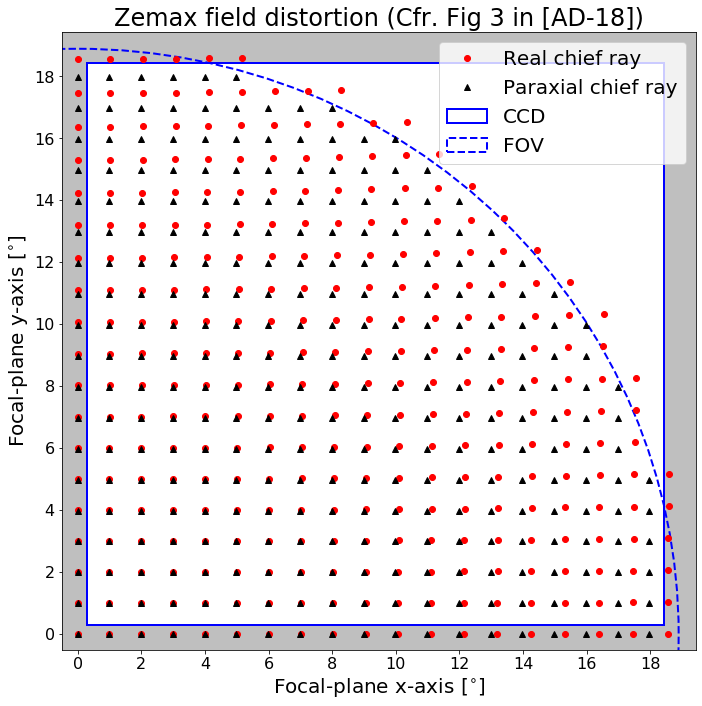

In [39]:
import shapely.geometry as sg
import descartes


# Re-shaping

xParaxialDegreesReshaped = xParaxialDegrees.reshape(181, 181)
xRealDegreesReshaped = xRealDegrees.reshape(181, 181)

yParaxialDegreesReshaped = yParaxialDegrees.reshape(181, 181)
yRealDegreesReshaped = yRealDegrees.reshape(181, 181)

# Visualise distortion in steps of 1° and only within the FOV (i.e. radius <= 18.8876°) 

step = 10

radiusParaxialReshaped = np.sqrt(np.power(xParaxialDegreesReshaped[::step,::step], 2) + np.power(yParaxialDegreesReshaped[::step,::step], 2))
fovSelection = radiusParaxialReshaped <= fovDegrees

fig = plt.figure(figsize=(25,25))
ax = plt.subplot(221)

plt.plot(xRealDegreesReshaped[::step,::step][fovSelection], yRealDegreesReshaped[::step,::step][fovSelection], "ro", label = "Real chief ray")
plt.plot(xParaxialDegreesReshaped[::step,::step][fovSelection], yParaxialDegreesReshaped[::step,::step][fovSelection], "k^", label = "Paraxial chief ray")



start = np.rad2deg(np.arctan(1.3 / focalLengthMm))
end = np.rad2deg(np.arctan(82.48 / focalLengthMm))

rect = plt.Rectangle((start-1, start-1), 21, 21, 0.0, alpha = 0.5, linewidth = 2)
ax.add_patch(rect)
rect.set_edgecolor("none")
rect.set_facecolor("gray")

rect = plt.Rectangle((start, start), end-start, end-start, 0.0, alpha = 1, linewidth = 2, label="CCD")
ax.add_patch(rect)
rect.set_edgecolor("b")
rect.set_facecolor("white")

circ = plt.Circle((0,0), radius = fovDegrees, color = "white", linewidth = 2, label = "FOV", linestyle="--")
ax.add_patch(circ)
circ.set_edgecolor("b")
circ.set_facecolor("none")

# print(start, end)
# plt.axvspan(-0.5, start, facecolor='0.2', alpha=0.5)
# plt.axvspan(end, end + 1, facecolor='0.2', alpha=0.5)
# plt.axhspan(-0.5, start, facecolor='0.2', alpha=0.5)
# plt.axhspan(end, end + 1, facecolor='0.2', alpha=0.5)

plt.title("Zemax field distortion (Cfr. Fig 3 in [AD-18])", fontsize = 24)
plt.xlabel("Focal-plane x-axis [$^{\circ}$]", fontsize = 20)
plt.ylabel("Focal-plane y-axis [$^{\circ}$]", fontsize = 20)

plt.legend(prop={'size': 20})
plt.xlim([-0.5, end + 1])
plt.ylim([-0.5, end + 1])
major_ticks = np.arange(0, 20, 2)
ax.set_xticks(major_ticks)
ax.set_yticks(major_ticks)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

In [40]:
# Read the distortion file

xDeg, yDeg, radius, xReal, yReal, xParaxial, yParaxial, vignetted = \
    np.loadtxt("PLATO_Field_Distortion.txt", unpack=True)

# Real chief ray: [mm] -> [pixels]

xRealPixels = xReal / (pixelSize / c.milli * c.micro)
yRealPixels = yReal / (pixelSize / c.milli * c.micro)

# Paraxial chief ray: [mm] -> [pixels]

xParaxialPixels = xParaxial / (pixelSize / c.milli * c.micro)
yParaxialPixels = yParaxial / (pixelSize / c.milli * c.micro)

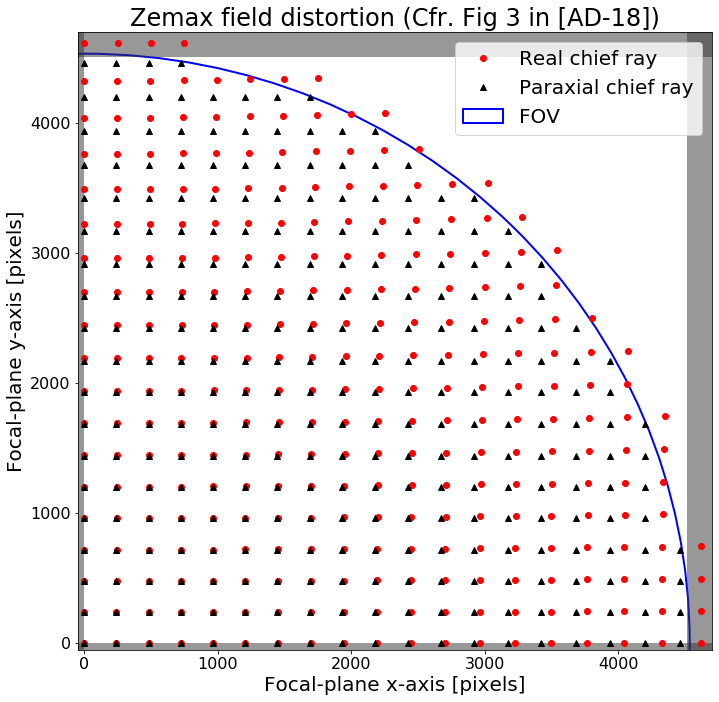

In [41]:
# Re-shaping

xParaxialPixelsReshaped = xParaxialPixels.reshape(181, 181)
xRealPixelsReshaped = xRealPixels.reshape(181, 181)

yParaxialPixelsReshaped = yParaxialPixels.reshape(181, 181)
yRealPixelsReshaped = yRealPixels.reshape(181, 181)

# Visualise distortion in steps of 1° and only within the FOV (i.e. radius <= 18.8876°) 

step = 10

radiusParaxialReshaped = np.sqrt(np.power(xParaxialPixelsReshaped[::step,::step], 2) + np.power(yParaxialPixelsReshaped[::step,::step], 2))
fovSelection = radiusParaxialReshaped <= fovPixels

fig = plt.figure(figsize=(25,25))
ax = plt.subplot(221)

plt.plot(xRealPixelsReshaped[::step,::step][fovSelection], yRealPixelsReshaped[::step,::step][fovSelection], "ro", label = "Real chief ray")
plt.plot(xParaxialPixelsReshaped[::step,::step][fovSelection], yParaxialPixelsReshaped[::step,::step][fovSelection], "k^", label = "Paraxial chief ray")

circ = plt.Circle((0,0), radius = fovPixels, color = "white", linewidth = 2, label = "FOV")
ax.add_patch(circ)
circ.set_edgecolor("b")
circ.set_facecolor("w")

# rect = plt.Rectangle((0, 0), 4510, 4510, 0.0, alpha = 0.5, linewidth = 2)
# ax.add_patch(rect)
# rect.set_edgecolor("b")
# rect.set_facecolor("w")

plt.axvspan(-50, 0, facecolor='0.2', alpha=0.5)
plt.axvspan(4510, 4700, facecolor='0.2', alpha=0.5)
plt.axhspan(-50, 0, facecolor='0.2', alpha=0.5)
plt.axhspan(4510, 4700, facecolor='0.2', alpha=0.5)

plt.title("Zemax field distortion (Cfr. Fig 3 in [AD-18])", fontsize = 24)
plt.xlabel("Focal-plane x-axis [pixels]", fontsize = 20)
plt.ylabel("Focal-plane y-axis [pixels]", fontsize = 20)

plt.legend(prop={'size': 20})
plt.xlim([-50, 4700])
plt.ylim([-50, 4700])
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

In [42]:
# Field radius [pixels] of the undistorted and distorted positions

radiusPixelsUndistorted = np.sqrt(np.power(xParaxialPixels, 2) + np.power(yParaxialPixels, 2))
radiusPixelsDistorted = np.sqrt(np.power(xRealPixels, 2) + np.power(yRealPixels, 2))

# Field radius of the undistorted positions [degrees]

radiusDegUndistorted = np.zeros(len(radius))

for index in range(len(radius)):
    radiusDegUndistorted[index] = rf.gnomonicRadialDistanceFromOpticalAxis(xParaxial[index], yParaxial[index], focalLengthMm)

radiusDegUndistorted = np.rad2deg(radiusDegUndistorted)   # Conversion [radians] -> [degrees]

# Field radius of the distorted positions [degrees]

radiusDegDistorted = np.zeros(len(radius))

for index in range(len(radius)):
    radiusDegDistorted[index] = rf.gnomonicRadialDistanceFromOpticalAxis(xReal[index], yReal[index], focalLengthMm)

radiusDegDistorted = np.rad2deg(radiusDegDistorted)   # Conversion [radians] -> [degrees]

# Distortion

distortionX = xRealPixels - xParaxialPixels    # Distortion in the X-direction [pixels]
distortionY = yRealPixels - yParaxialPixels    # Distortion in the Y-direction [pixel]

distortion = np.sqrt(np.power(distortionX, 2) + np.power(distortionY, 2))   # Distortion in the radial direction (away from the optical axis)

## Undistorted -> distorted

Radial distortion model (pincushion/barrel distortion):

$$\rm{distortion} = r \cdot (k_1 \cdot r^2 + k_2 \cdot r^4 + k_3 \cdot r^6)$$

where the distortion is expressed in normalised pixels and $r$ is the __undistorted__ field radius, expressed in normalised pixels.

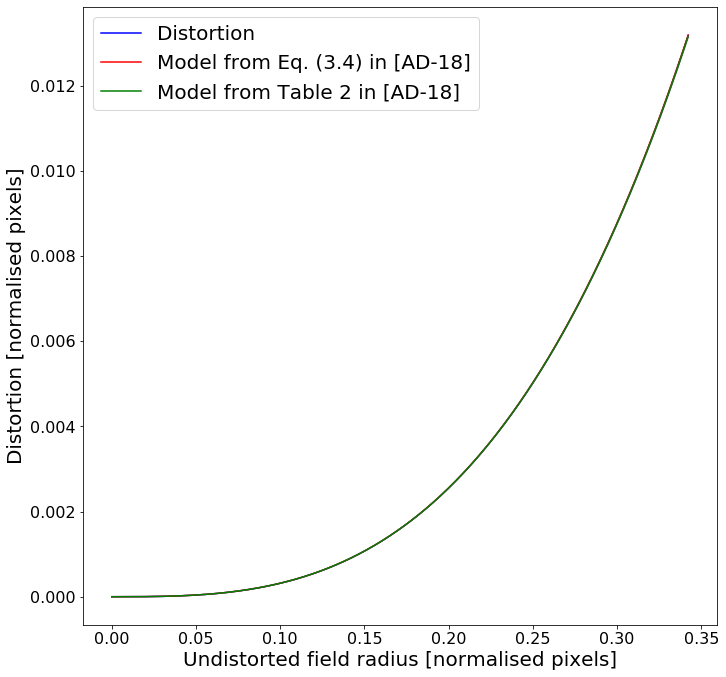

Fit parameters: undistorted -> distorted:
* k1: 0.31625860529941946
* k2: 0.06633092013805682
* k3: 0.3728821588437887


In [43]:
# Select undistorted positions within the FOV

fovSelectionU2D = (radiusDegUndistorted <= fovDegrees)

radiusPixelsU2D = radiusPixelsUndistorted[fovSelectionU2D]
distortionU2D = distortion[fovSelectionU2D]

# Sort by increasing radius

indices = np.argsort(radiusPixelsU2D)

radiusPixelsU2D = radiusPixelsU2D[indices]
distortionU2D = distortionU2D[indices]

# Normalisation: divide out the focal length

radiusPixelsU2D /= focalLengthPixels
distortionU2D /= focalLengthPixels

# Distortion model described in Eq. (3.4) in PLATO-DLR-PL-TN-016

p_init = models.Polynomial1D(degree = 7, c0 = 0, c1 = 0, c2 = 0, c4 = 0, c6 = 0)

p_init.c0.fixed = True
p_init.c1.fixed = True
p_init.c2.fixed = True
p_init.c4.fixed = True
p_init.c6.fixed = True

fit_p = fitting.LevMarLSQFitter()
p = fit_p(p_init, radiusPixelsU2D, distortionU2D)

# Model with parameters values taken from Table 2 in [AD-18]

pDenis_init = models.Polynomial1D(degree = 7, c0 = 0, c1 = 0, c2 = 0, c3 = 0.3160, c4 = 0, c5 = 0.0553, c6 = 0, c7 = 0.4177)

pDenis_init.c0.fixed = True
pDenis_init.c1.fixed = True
pDenis_init.c2.fixed = True
pDenis_init.c3.fixed = True
pDenis_init.c4.fixed = True
pDenis_init.c5.fixed = True
pDenis_init.c6.fixed = True
pDenis_init.c7.fixed = True

fit_pDenis = fitting.LevMarLSQFitter()
pDenis = fit_p(pDenis_init, radiusPixelsU2D, distortionU2D)

# Plotting

fig = plt.figure(figsize=(25,25))
plt.subplot(221)

plt.plot(radiusPixelsU2D, distortionU2D, "b", label = "Distortion")
plt.plot(radiusPixelsU2D, p(radiusPixelsU2D), "r-", label = "Model from Eq. (3.4) in [AD-18]")
plt.plot(radiusPixelsU2D, pDenis(radiusPixelsU2D), "g-", label = "Model from Table 2 in [AD-18]")
plt.xlabel("Undistorted field radius [normalised pixels]", fontsize = 20)
plt.ylabel("Distortion [normalised pixels]", fontsize = 20)
plt.legend(prop={'size': 20})
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

print("Fit parameters: undistorted -> distorted:")
print("* k1:", p.c3.value)
print("* k2:", p.c5.value)
print("* k3:", p.c7.value)

In [44]:
distortionAtEdge = p(fovPixels / focalLengthPixels)
distortionAtEdgeDenis = pDenis(fovPixels / focalLengthPixels)

print("Distortion at the edge of the FOV:", str(distortionAtEdge / fovPixels * focalLengthPixels * 100.0) + "%")
print("Distortion at the edge of the FOV (Denis):", str(distortionAtEdgeDenis / fovPixels * focalLengthPixels * 100.0) + "%")
print("Compare with req. 445: 3.84%")

Distortion at the edge of the FOV: 3.5642242129097834%
Distortion at the edge of the FOV (Denis): 3.554134924205417%
Compare with req. 445: 3.84%


## Distorted -> undistorted

Radial distortion model (pincushion/barrel distortion):

$$\rm{distortion} = r \cdot (k_1 \cdot r^2 + k_2 \cdot r^4 + k_3 \cdot r^6)$$

where the distortion is expressed in normalised pixels and $r$ is the __distorted__ field radius, expressed in normalised pixels.

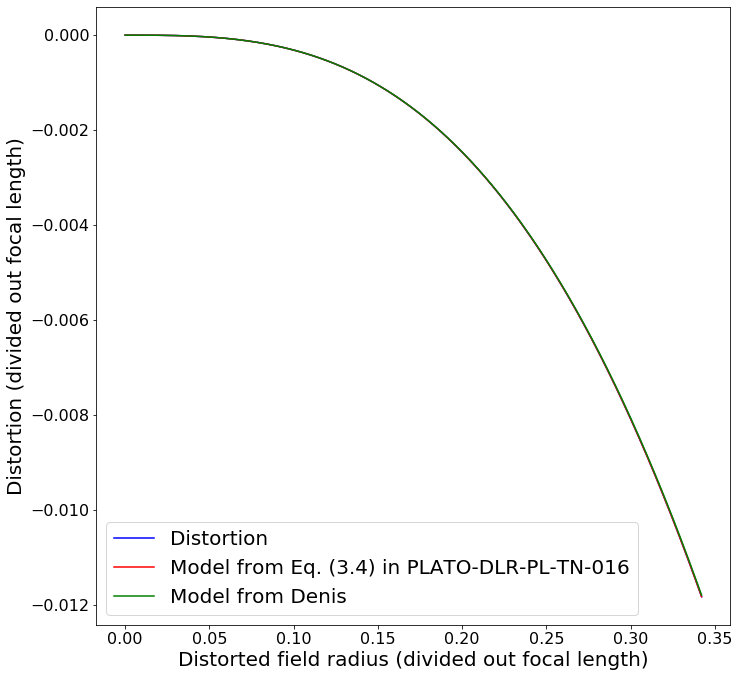

Fit parameters: distorted -> undistorted:
* k1: -0.31582720856310026
* k2: 0.21497088555242796
* k3: -0.32367738676584085


In [45]:
# Select undistorted positions within the FOV

fovSelectionD2U = (radiusDegDistorted <= fovDegrees)

radiusPixelsD2U = radiusPixelsDistorted[fovSelectionD2U]
distortionD2U = distortion[fovSelectionD2U]

# Sort by increasing radius

indices = np.argsort(radiusPixelsD2U)

radiusPixelsD2U = radiusPixelsD2U[indices]
distortionD2U = distortionD2U[indices]

radiusPixelsD2U /= focalLengthPixels
distortionD2U *= (-1)
distortionD2U /= focalLengthPixels

# Distortion model described in Eq. (3.4) in [AD-18]

p_init = models.Polynomial1D(degree = 7, c0 = 0, c1 = 0, c2 = 0, c4 = 0, c6 = 0)

p_init.c0.fixed = True
p_init.c1.fixed = True
p_init.c2.fixed = True
p_init.c4.fixed = True
p_init.c6.fixed = True

fit_p = fitting.LevMarLSQFitter()
p = fit_p(p_init, radiusPixelsD2U, distortionD2U)

pDenis_init = models.Polynomial1D(degree = 7, c0 = 0, c1 = 0, c2 = 0, c3 = -0.3155, c4 = 0, c5 = 0.2245, c6 = 0, c7 = 0-0.3706)

pDenis_init.c0.fixed = True
pDenis_init.c1.fixed = True
pDenis_init.c2.fixed = True
pDenis_init.c3.fixed = True
pDenis_init.c4.fixed = True
pDenis_init.c5.fixed = True
pDenis_init.c6.fixed = True
pDenis_init.c7.fixed = True

fit_pDenis = fitting.LevMarLSQFitter()
pDenis = fit_p(pDenis_init, radiusPixelsD2U, distortionD2U)


# Plotting

fig = plt.figure(figsize=(25,25))
plt.subplot(221)

plt.plot(radiusPixelsD2U, distortionD2U, "b", label = "Distortion")
plt.plot(radiusPixelsD2U, p(radiusPixelsD2U), "r-", label = "Model from Eq. (3.4) in PLATO-DLR-PL-TN-016")
plt.plot(radiusPixelsD2U, pDenis(radiusPixelsD2U), "g-", label = "Model from Denis")
plt.xlabel("Distorted field radius (divided out focal length)", fontsize = 20)
plt.ylabel("Distortion (divided out focal length)", fontsize = 20)
plt.legend(prop={'size': 20})
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.show()

print("Fit parameters: distorted -> undistorted:")
print("* k1:", p.c3.value)
print("* k2:", p.c5.value)
print("* k3:", p.c7.value)

# Gaussian PSF
* Mask size: req. 450 in [AD-2] - [AD-7]
* Percentage of enclosed energy: req. 460 in [AD-2] - [AD-7]

In [46]:
maskSize = 1.0           # Square mask of 2.5 x 2.5 pixel
ensquaredEnergy = 0.32   # 90% of the PSF's energy should be ensquared by the mask

In [47]:
# See https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule

n = scipy.special.erfinv(math.sqrt(ensquaredEnergy)) * math.sqrt(2)
sigmaPsf = (maskSize / 2.0) / n

print("Sigma for the Gaussian PSF:", sigmaPsf, "pixels")

# math.erf(n / math.sqrt(2))**2 # Enclosed energy

Sigma for the Gaussian PSF: 0.6395253379543886 pixels


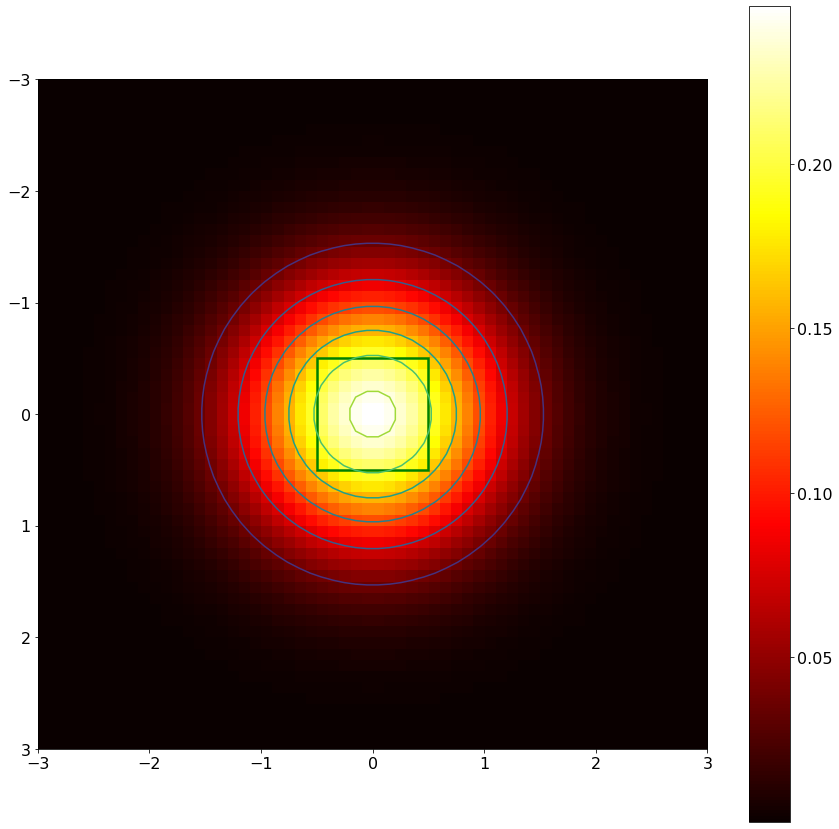

In [48]:
N = 60
X = np.linspace(-3, 3, N)
Y = np.linspace(-3, 3, N)
X, Y = np.meshgrid(X, Y)


centroid = np.array([0., 0.])
covarianceMatrix = np.array([[ sigmaPsf , 0.0], [0.0,  sigmaPsf]])

# Pack X and Y into a single 3-dimensional array
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

def multivariate_gaussian(pos, centroid, covarianceMatrix):
    """Return the multivariate Gaussian distribution on array pos.

    pos is an array constructed by packing the meshed arrays of variables
    x_1, x_2, x_3, ..., x_k into its _last_ dimension.

    """

    n = centroid.shape[0]
    detCovarianceMatrix = np.linalg.det(covarianceMatrix)
    inverseCovarianceMatrix = np.linalg.inv(covarianceMatrix)
    N = np.sqrt((2*np.pi)**n * detCovarianceMatrix)
    # This einsum call calculates (x-mu)T.Sigma-1.(x-mu) in a vectorized
    # way across all the input variables.
    fac = np.einsum('...k,kl,...l->...', pos-centroid, inverseCovarianceMatrix, pos-centroid)

    return np.exp(-fac / 2) / N

Z = multivariate_gaussian(pos, centroid, covarianceMatrix)

fig,ax = plt.subplots(figsize=(15,15))
plt.imshow(Z, extent=[-3,3, -3,3], cmap=cm.hot, interpolation="nearest")
plt.gca().invert_yaxis()
cbar = plt.colorbar()

rect = patches.Rectangle((-1.25 + 1.5/2.0,-1.25 + 1.5/2.0),1,1,linewidth=2.5,edgecolor='g',facecolor='none')
#rect = patches.Rectangle((-1.25,-1.25),2.5,2.5,linewidth=2.5,edgecolor='g',facecolor='none')
ax.add_patch(rect)
plt.contour(Z, extent=[-3,3, -3,3])
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
cbar.ax.tick_params(labelsize = 16) 
plt.show()

# Charge diffusion & jitter smoothing

In [49]:
chargeDiffusionStrength = 0.2    # [pixels]
jitterSmoothingStrength = 0.5    # [sub-pixels]

print("Width of the Gaussian diffusion kernel (for charge diffusion):", chargeDiffusionStrength, "pixels")
print("Jitter smoothing corresponds to applying a Gaussian diffusion kernel with a width of", jitterSmoothingStrength, "sub-pixels")

Width of the Gaussian diffusion kernel (for charge diffusion): 0.2 pixels
Jitter smoothing corresponds to applying a Gaussian diffusion kernel with a width of 0.5 sub-pixels


# Nominal operating temperature of the FEE
[AD-16]

In [50]:
nominalTemperatureFEE = -63     # Nominal operating temperature of the FEE [°C]

print("Nominal operating temperature of the FEE:", nominalTemperatureFEE, "°C")

Nominal operating temperature of the FEE: -63 °C


# Readout noise FEE

Req. 860 in [AD-2] - [AD-7]

In [51]:
readoutNoiseNormalBOL = 32.0   # Readout noise for the normal cameras [e- / pixel]
readoutNoiseNormalEOL = 37.0   # Readout noise for the normal cameras [e- / pixel]
readoutNoiseFastEOL = 200      # Readout noise for the fast cameras [e- / pixel]

print("Readout noise for the FEE (normal cameras, BOL):", readoutNoiseNormalBOL, "e- / pixel")
print("Readout noise for the FEE (normal cameras, EOL):", readoutNoiseNormalEOL, "e- / pixel")
print("Readout noise for the FEE (fast cameras, EOL):", readoutNoiseFastEOL, "e- / pixel")

Readout noise for the FEE (normal cameras, BOL): 32.0 e- / pixel
Readout noise for the FEE (normal cameras, EOL): 37.0 e- / pixel
Readout noise for the FEE (fast cameras, EOL): 200 e- / pixel


# Gain
* Total gain: req. 880 in [AD-2] - [AD-7]
* Temperature stability of the FEE gain: req. 840 in [AD-2] - [AD-6]
* CCD gain: req. 680 in [AD-2] - [AD7]
* Temperature stability of the CCD gain: Sect. 5.2.2.5 in [AD-9]

In [52]:
# Total gain [e- / ADU]

totalGainNormal = 25    # Total gain for the normal cameras
totalGainFast = 15      # Total gain for the fast cameras

# CCD gain

gainCCD = 1.8                 # CCD gain [µV / e-]
gainStabilityCCD = 0.1e-2     # Temperature stability of the CCD gain [µV / e- / K]

# FEE gain

gainNormalFEE = 1 / gainCCD / totalGainNormal   # FEE gain for the normal camera [ADU / µV]
gainFastFEE = 1 / gainCCD / totalGainFast       # FEE gain for the fast camera [ADU / µV]
gainStabilityFEE = 300e-6                       # Temperature stability of the FEE gain [ADU / µV / K]

print("CCD gain:", gainCCD, "µV / e- (temperature stability:", gainStabilityCCD ,"µV / e- / K)\n")

print("FEE gain (normal cameras):", gainNormalFEE, "ADU / µV (temperature stability:", gainStabilityFEE ,"ADU / µV / K)")
print("FEE gain (fast cameras):", gainFastFEE, "ADU / µV (temperature stability:", gainStabilityFEE ,"ADU / µV / K)")

CCD gain: 1.8 µV / e- (temperature stability: 0.001 µV / e- / K)

FEE gain (normal cameras): 0.022222222222222223 ADU / µV (temperature stability: 0.0003 ADU / µV / K)
FEE gain (fast cameras): 0.03703703703703704 ADU / µV (temperature stability: 0.0003 ADU / µV / K)


# Electronic offset
* Electronic offset: no value available
* Temperature stability of the electronic offset: req. 850 in [AD-2] - [AD-7]

In [53]:
electronicOffset = None     # Electronic offset [ADU / pixel]

electronicOffsetStabilityNormal = 1     # Temperature stability of the electronic offset for normal cameras [ADU / K]
electronicOffsetStabilityFast = 1      # Temperature stability of the electronic offset for fast cameras [ADU / K]

print("Electronic offset (normal cameras):", electronicOffset, "ADU / pixel (temperature stability:", electronicOffsetStabilityNormal ,"ADU / pixel / K)")
print("Electronic offset (fast cameras):", electronicOffset, "ADU / pixel (temperature stability:", electronicOffsetStabilityFast ,"ADU / pixel / K)")

Electronic offset (normal cameras): None ADU / pixel (temperature stability: 1 ADU / pixel / K)
Electronic offset (fast cameras): None ADU / pixel (temperature stability: 1 ADU / pixel / K)


# Nominal operating temperature of the CCD
Req. CC-GEN-008 in [AD-16]

In [54]:
nominalTemperatureCCD = -70    # Nominal operating temperature of the CCD [°C]

print("Nominal operating temperature of the CCD:", nominalTemperatureCCD, "°C")

Nominal operating temperature of the CCD: -70 °C


# Full-well saturation (blooming)
Req. 640 in [AD-2] - [AD-7]

In [59]:
fullWellSaturation = 900000 # Full-well saturation limit [e- / pixel]

print("Full-well saturation:", fullWellSaturation, "e- / pixel")

Full-well saturation: 900000 e- / pixel


# Digital saturation
Req. 870 in [AD-2] - [AD-7]

In [60]:
def getDigitalSaturation(numBits):
    
    """
    Converts the number of ADC quantisation bits  into the digital
    saturation limit, expressed in [ADU / pixel].
    
    INPUT:
        - numBits: Number of ADC quantisation bits.
        
    OUTPUT: Digital saturation limit [ADU / pixel].
    """
    
    return int(math.pow(2, numBits) - 1)

In [61]:
quantisationNormal = 16   # ADC quantisation for normal cameras [bits]
quantisationFast = 16     # ADC quantisation for fast cameras [bits]

digitalSaturationNormal = getDigitalSaturation(quantisationNormal)   # Digital-saturation limit for normal cameras [ADU / pixel]
digitalSaturationFast = getDigitalSaturation(quantisationFast)       # Digital-saturation limit for fast cameras [ADU / pixel]

print("Digital saturation (normal cameras):", digitalSaturationNormal, "ADU / pixel")
print("Digital saturation (fast cameras):", digitalSaturationFast, "ADU / pixel")

Digital saturation (normal cameras): 65535 ADU / pixel
Digital saturation (fast cameras): 65535 ADU / pixel


# Readout noise CCD
Req. 780 in [AD-2] - [AD-7]

In [62]:
readoutNoiseBOL = 38.7  # Readout noise at BOL [e-]
readoutNoiseEOL = 44.3  # Readout noise at EOL [e-]

print("Readout noise for the CCD (BOL):", readoutNoiseBOL, "e-")
print("Readout noise for the CCD (EOL):", readoutNoiseEOL, "e-")

Readout noise for the CCD (BOL): 38.7 e-
Readout noise for the CCD (EOL): 44.3 e-


# Readout time
* Exposure time: see above
* Cadence: req. 300 in [AD-2] - [AD-7]
* Transfer times: [AD-20]

In [63]:
"""
cadenceNormal = 25      # Cademce for the normal cameras [s]
cadenceFast = 2.5       # Cadence for the fast cameras[s]

readoutTimeNormal = cadenceNormal - exposureTimeNormal   # Readout time for the normal cameras [s]
readoutTimeFast = cadenceFast - exposureTimeFast   # Readout time for the fast cameras [s]

print("Readout time (normal cameras):", readoutTimeNormal, "s")
print("Readout time (fast cameras):", readoutTimeFast, "s")
"""

'\ncadenceNormal = 25      # Cademce for the normal cameras [s]\ncadenceFast = 2.5       # Cadence for the fast cameras[s]\n\nreadoutTimeNormal = cadenceNormal - exposureTimeNormal   # Readout time for the normal cameras [s]\nreadoutTimeFast = cadenceFast - exposureTimeFast   # Readout time for the fast cameras [s]\n\nprint("Readout time (normal cameras):", readoutTimeNormal, "s")\nprint("Readout time (fast cameras):", readoutTimeFast, "s")\n'

In [64]:
serialTransferTime = 340          # Serial transfer time [ns]
parallelTransferTime = 110        # Parallel transfer time[µs]
parallelTransferTimeFast = 90     # Parallel transfer time fast [µs]

print("Time needed to shift the content of the readout register over one pixel (towards the output node):", serialTransferTime, "ns")
print("Time to shift the charges one row down in case the readout register will be read out:", parallelTransferTime, "µs")
print("Time to shift the charges one row down in case the readout register will not be read out:", parallelTransferTimeFast, "µs")

Time needed to shift the content of the readout register over one pixel (towards the output node): 340 ns
Time to shift the charges one row down in case the readout register will be read out: 110 µs
Time to shift the charges one row down in case the readout register will not be read out: 90 µs


# Flatfield
Req. 730 in [AD-2] - [AD-7]

In [65]:
FlatfieldNoiseRMS = 0.010

print("Flatfield noise RMS (local PRNU):", FlatfieldNoiseRMS)

Flatfield noise RMS (local PRNU): 0.01


# Vignetting
Req. 520 in [AD-2] - [AD-7]

The efficiency caused by natural vignetting can be modelled as

$$E_{\rm vig.}(i,j) = \cos^2{(\theta(i,j))}.$$

In [66]:
# efficiencyVignetting = np.zeros((numRows, numColumns))
# expectedEfficiencyVignetting = 0

# for row in range(numRows):
    
#     yFP = row * pixelSize * constants.micro / constants.milli + halfButtingDistance
    
#     for column in range(numColumns):
        
#         xFP = column * pixelSize * constants.micro / constants.milli + halfButtingDistance
        
#         angularDistance = rf.gnomonicRadialDistanceFromOpticalAxis(xFP, yFP, focalLength / constants.milli)# Radians
        
#         g = math.pow(np.cos(angularDistance), 2)
        
#         efficiencyVignetting[row][column] = g
#         expectedEfficiencyVignetting += g

# expectedEfficiencyVignetting /= (numRows * numColumns)

# print("Expected efficiency caused by vignetting:", expectedEfficiencyVignetting)

# print("Reason that this value deviates from the expected value of 0.945:")
# print("- mechanical vignetting is not included")
# print("- the model for the natural vignetting is merely an approximation")

In [67]:
# expectedEfficiencyVignettingBOL = 0.904
# expectedEfficiencyVignettingEOL = 0.902

# print("Expected efficiency caused by vignetting (BOL):", expectedEfficiencyVignettingBOL)
# print("Expected efficiency caused by vignetting (EOL):", expectedEfficiencyVignettingEOL)

In [77]:
# fig,ax = plt.subplots(figsize=(15,15))
# plt.imshow(efficiencyVignetting, cmap=cm.hot, interpolation="nearest")

# plt.gca().invert_yaxis()
# cbar = plt.colorbar()
# plt.contour(efficiencyVignetting)
# plt.title("Vignetting", fontsize = 24)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# cbar.ax.tick_params(labelsize = 16) 

# plt.show()

In [68]:
# fieldRadiusVignetting = np.arange(0, 19.0)
# fieldRadiusVignetting = np.append(fieldRadiusVignetting, 18.8875)

# naturalVignetting = np.array([0.00, 0.03, 0.12, 0.27, 0.49, 0.76, 1.09, 1.49, 1.94, 2.45, 3.02, 3.64, 4.32, 5.06, 5.85, 6.70, 7.60, 8.55, 9.55, 10.48])
# mechanicalVignetting = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.04, 0.38, 0.97, 2.06, 3.62])

In [69]:
# plt.figure(figsize=(25,25))
# plt.subplot(221)

# plt.plot(fieldRadiusVignetting, naturalVignetting, "bo", label = "Natural")
# plt.plot(fieldRadiusVignetting, mechanicalVignetting, "ro", label = "Mecchanical")
# plt.plot(fieldRadiusVignetting, naturalVignetting + mechanicalVignetting, "go-", label = "Overall")
# plt.plot(fieldRadiusVignetting, 100.0 * np.sin(np.radians(fieldRadiusVignetting))**2, "k--", label = r'$1 - \sin^2{(\theta)}$')
# #plt.plot(fieldRadiusVignetting, np.exp((fieldRadiusVignetting - 14)) * 3.62 / math.exp(18.8875 - 14), "k--", label = r'$100 \cdot \exp{(\theta - 14) \cdot 3.62 / \exp(4.8875)}$')
# plt.axvspan(-1, 0, facecolor='0.2', alpha=0.5)
# plt.axvspan(18.8875, 20, facecolor='0.2', alpha=0.5)

# plt.legend(prop={'size': 20})
# plt.xlabel(r'$\rm{Field\,radius} [^{\circ}]$', fontsize = 20)
# plt.ylabel("Vignetting", fontsize = 20)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.title("Vignetting", fontsize = 24)
# plt.xlim([-0.5, 18.7765+0.5])

# plt.show()

# Dark signal
* Dark current: req. 700 in [AD-2] - [AD-7]
* Temperature stability of the dark current: 
* Dark-signal non-uniformity (DSNU): Sect. 5.1.1.3 in [AD-9]

In [60]:
darkCurrentBOL = 1.2    # Dark current at BOL [e- / s / pixel]
darkCurrentEOL = 4.5    # Dark current at EOL [e- / s / pixel]

darkCurrentStability = 5.0  # Temperature stability of the dark current [e- / s / pixel / K]

dsnu = 15   # Dark-signal non-uniformity

print("Dark signal (BOL):", darkCurrentBOL, "e- / s / pixel (temperature stability:", darkCurrentStability, "e- / s / pixel / K)")
print("Dark signal (EOL):", darkCurrentEOL, "e- / s / pixel (temperature stability:", darkCurrentStability, "e- / s / pixel / K)")
print("Dark-signal non-uniformity:", str(dsnu) + "%")

Dark signal (BOL): 1.2 e- / s / pixel (temperature stability: 5.0 e- / s / pixel / K)
Dark signal (EOL): 4.5 e- / s / pixel (temperature stability: 5.0 e- / s / pixel / K)
Dark-signal non-uniformity: 15%


# CTI
## Simple

* CTI values for parallel transfers: req. 750 in old version of [AD-2] - [AD-7]
* CTI values for serial transfers: req. 760 in old version of [AD-2] - [AD-7]
* Expected efficiency caused by CTI : req. 770 in old version of [AD-2] - [AD-7]

<!-- * Expected efficiency caused by CTI: Eq. 4-14 in [AD-9]
* Empirical model for the intercept in the log-log plot
    * a: req. 754 in [AD-2] - [AD-7]
    * b: req. 756 in [AD-2] - [AD-7]
    * c: req. 758 in [AD-2] - [AD-7]
* Empirical model for the number of photoelectrons per pixels for a target star: [AD-17]
    * m: req. 752 in [AD-2] - [AD-7]
* Ratio between the CTI values for serial and parallel transfers: req. 762 in [AD-2] - [AD-7]
* Radiation level: req. 395 in [AD-2] - [AD-7]
* Magnitude target star: req. 080 in [AD-2] - [AD-7]
* Photon density for target star: Table 4-1 in [AD-9]
* Number of target photons: Eq. 4-6 in [AD-9] -->

Since the  left- and right-hand side of the CCDs are read out separately (with their own readout register and electronics), the efficiency caused by CTI for pixel (row, column) is

$$E_{\rm CTI} (row, column) = (1 - CTI_{\rm parallel})^{\rm row} \cdot (1 - CTI_{\rm serial})^{\rm  max \{column, 4510 - column + 1\}} .$$

In [61]:
def getExpectedEfficiencyCTI(ctiParallel, ctiSerial):
    
    """
    Calculates the expected efficiency caused by CTI (Eq. 4-14 in [AD-9]).
    
    INPUT:
        - ctiParallel: CTI value for parallel transfers
        - ctiSerial: CTI value for serial transfers
    
    OUTPUT: Expected efficiency caused by CTI.
    """
    
    expectedEfficiency = 0
    
    for row in range(numRows):
        
        for column in range(numColumns):
            
            expectedEfficiency += math.pow(1 - ctiParallel, row) * math.pow(1 - ctiSerial, column)
    
    return expectedEfficiency / (numRows * numColumns)

In [62]:
def getCtiIntercept(a, b, c, radiationLevel):
    
    """
    Calculates the intercept in the log-log plot, based on the radiation level, 
    as decribed by the empirical model from [AD-17]).
    
    Empirical model: n = f(R) = a * R**2 + b * R + c
    
    INTPUT:
        - a: Coefficient for the 2nd-order term in the empirical model
        - b: Coefficient for the 1st-order term in the empirical model
        - c: Coefficient for the 0th-order term in the empirical model
        - radiationLevel:  Radiation level [protons / cm^2]
    
    OUTPUT: Intercept in the log-log plot, depending on radiation level.
    """
    
    return a * radiationLevel**2 + b * radiationLevel + c

In [63]:
def getCtiParallel(a, b, c, m, numPhotoElectrons, radiationLevel):
    
    """
    Calculates the value for the CTI for parallel transfers, as
    described by the empirical model from [AD-17].
    
    Empirical model: CTI_parallel = n_pe**m * 10**n
    
    INPUT:
        - a: Coefficient for the 2nd-order term in the empirical model
        - b: Coefficient for the 1st-order term in the empirical model
        - c: Coefficient for the 0th-order term in the empirical model
        - numPhotoElectrons: Number of photoelectrons per pixel for a target star
        - radiationLevel: Radiation level [protons / cm^2]
    
    OUTPUT: CTI value for parallel transfers.
    """
    
    n = getCtiIntercept(a, b, c, radiationLevel)
    
    print("n:", n)
    
    return math.pow(numPhotoElectrons, m) * math.pow(10, n)

In [64]:
def getCtiSerial(ctiParallel, ctiRatio):
    
    """
    Calculates the value for the CTI for serial transfers, based on
    the value for the CTI for parallel transfers.
    
    INTPUT:
        - ctiParallel: CTI value for parallel transfers
        - ctiRatio: ratio between the CTI values for serial and parallel transfers
        
    OUTPUT: CTI value for serial transfers.
    """
    
    return ctiRatio * ctiParallel

In [65]:
# Normal camera

parallelCTINormalBOL = 5.42e-6
serialCTINormalBOL = 5.42e-7
expectedEfficiencyCTINormalBOL = 0.987

parallelCTINormalEOL = 4.97e-5
serialCTINormalEOL = 4.97e-6
expectedEfficiencyCTINormalEOL = 0.891

# Fast blue camera

parallelCTIFastBlueBOL = 8.13e-6
serialCTIFastBlueBOL = 8.13e-7
expectedEfficiencyCTIFastBlueBOL = 0.981

parallelCTIFastBlueEOL = 7.48e-5
serialCTIFastBlueEOL = 7.48e-6
expectedEfficiencyCTIFastBlueEOL = 0.842

# Fast red camera

parallelCTIFastRedBOL = 8.43e-6
serialCTIFastRedBOL = 8.43e-7
expectedEfficiencyCTIFastRedBOL = 0.981

parallelCTIFastRedEOL = 7.70e-5
serialCTIFastRedEOL = 7.70e-6
expectedEfficiencyCTIFastRedEOL = 0.838

print("CTI for normal cameras:\n")

print("Parallel CTI at BOL:", sci_str(parallelCTINormalBOL))
print("Serial CTI at BOL:", sci_str(serialCTINormalBOL))
print("Expected efficiency caused by CTI at BOL:", expectedEfficiencyCTINormalBOL,"\n")

print("Parallel CTI at EOL:", sci_str(parallelCTINormalEOL))
print("Serial CTI at EOL:", sci_str(serialCTINormalEOL))
print("Expected efficiency caused by CTI at EOL:", expectedEfficiencyCTINormalEOL, "\n")

print("CTI for fast blue cameras:\n")

print("Parallel CTI at BOL:", sci_str(parallelCTIFastBlueBOL))
print("Serial CTI at BOL:", sci_str(serialCTIFastBlueBOL))
print("Expected efficiency caused by CTI at BOL:", expectedEfficiencyCTIFastBlueBOL,"\n")

print("Parallel CTI at EOL:", sci_str(parallelCTIFastBlueEOL))
print("Serial CTI at EOL:", sci_str(serialCTIFastBlueEOL))
print("Expected efficiency caused by CTI at EOL:", expectedEfficiencyCTIFastBlueEOL, "\n")

print("CTI for fast red cameras:\n")

print("Parallel CTI at BOL:", sci_str(parallelCTIFastRedBOL))
print("Serial CTI at BOL:", sci_str(serialCTIFastRedBOL))
print("Expected efficiency caused by CTI at BOL:", expectedEfficiencyCTIFastRedBOL,"\n")

print("Parallel CTI at EOL:", sci_str(parallelCTIFastRedEOL))
print("Serial CTI at EOL:", sci_str(serialCTIFastRedEOL))
print("Expected efficiency caused by CTI at EOL:", expectedEfficiencyCTIFastRedEOL)

CTI for normal cameras:

Parallel CTI at BOL: 5.42E-6
Serial CTI at BOL: 5.42E-7
Expected efficiency caused by CTI at BOL: 0.987 

Parallel CTI at EOL: 4.97E-5
Serial CTI at EOL: 4.97E-6
Expected efficiency caused by CTI at EOL: 0.891 

CTI for fast blue cameras:

Parallel CTI at BOL: 8.13E-6
Serial CTI at BOL: 8.13E-7
Expected efficiency caused by CTI at BOL: 0.981 

Parallel CTI at EOL: 7.48E-5
Serial CTI at EOL: 7.48E-6
Expected efficiency caused by CTI at EOL: 0.842 

CTI for fast red cameras:

Parallel CTI at BOL: 8.43E-6
Serial CTI at BOL: 8.43E-7
Expected efficiency caused by CTI at BOL: 0.981 

Parallel CTI at EOL: 7.7E-5
Serial CTI at EOL: 7.7E-6
Expected efficiency caused by CTI at EOL: 0.838


In [66]:
"""
efficiencyCti = np.zeros((numRows, numColumns))

for row in range(numRows):
    for column in range(numColumns):
        
        efficiencyCti[row][column] = math.pow(1 - parallelCTINormalBOL, row) * math.pow(1 - serialCTINormalBOL, column)
"""

'\nefficiencyCti = np.zeros((numRows, numColumns))\n\nfor row in range(numRows):\n    for column in range(numColumns):\n        \n        efficiencyCti[row][column] = math.pow(1 - parallelCTINormalBOL, row) * math.pow(1 - serialCTINormalBOL, column)\n'

In [67]:
"""
plt.imshow(efficiencyCti)

plt.gca().invert_yaxis()
cbar = plt.colorbar()
plt.contour(efficiencyCti)
plt.title("CTI", fontsize = 24)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
cbar.ax.tick_params(labelsize = 16) 

plt.show()
"""

'\nplt.imshow(efficiencyCti)\n\nplt.gca().invert_yaxis()\ncbar = plt.colorbar()\nplt.contour(efficiencyCti)\nplt.title("CTI", fontsize = 24)\nplt.xticks(fontsize = 16)\nplt.yticks(fontsize = 16)\ncbar.ax.tick_params(labelsize = 16) \n\nplt.show()\n'

## Short et al.
[AD-13] and [RD-1]

In [13]:
numParticleSpecies = 4

temperature = 203
beta = 0.37

trapSpecies = ["fast", "intermediate", "intermediate", "slow"]
releaseTimeConstant = [2.37e-4, 2.43e-2, 2.03e-3, 1.40e-1]        # Release time constant (at 203 K)
trapDensityBOL = [0.0, 0.0, 0.0, 10.0]                            # Trap density at BOL [traps / pixel]
trapDensityEOL = [9.80, 3.31, 1.56, 13.24]                        # Trap density at EOL [traps / pixel]
captureCrossSection = [2.46e-20, 1.74e-22, 7.05e-23, 2.45e-23]    # Capture cross-section [m^-2]

print("Characteristics of the", numParticleSpecies, "trap species:\n")


for index in range(numParticleSpecies):
    
    print("(" + str(index + 1) + ")", trapSpecies[index], "trap species:")
    print("\t" + "- release time constant at", temperature, "K: " + str(releaseTimeConstant[index]))
    print("\t" + "- trap density at BOL: " + str(trapDensityBOL[index]), "traps/pixel")
    print("\t" + "- trap density at EOL: " + str(trapDensityEOL[index]), "traps/pixel")
    print("\t" + "- capture cross-section: " + str(captureCrossSection[index]), "m^-2")

Characteristics of the 4 trap species:

(1) fast trap species:
	- release time constant at 203 K: 0.000237
	- trap density at BOL: 0.0 traps/pixel
	- trap density at EOL: 9.8 traps/pixel
	- capture cross-section: 2.46e-20 m^-2
(2) intermediate trap species:
	- release time constant at 203 K: 0.0243
	- trap density at BOL: 0.0 traps/pixel
	- trap density at EOL: 3.31 traps/pixel
	- capture cross-section: 1.74e-22 m^-2
(3) intermediate trap species:
	- release time constant at 203 K: 0.00203
	- trap density at BOL: 0.0 traps/pixel
	- trap density at EOL: 1.56 traps/pixel
	- capture cross-section: 7.05e-23 m^-2
(4) slow trap species:
	- release time constant at 203 K: 0.14
	- trap density at BOL: 10.0 traps/pixel
	- trap density at EOL: 13.24 traps/pixel
	- capture cross-section: 2.45e-23 m^-2


# Sky background
* Background signal: req. 160 in [AD-2] - [AD-7]
* Radiation level: req. 395 in [AD-2] - [AD-7]
* Number of background photons: Eq. 4-7 in [AD-9]

The number of photoelectrons for backgound can be derived from the photon density _D_<sub>ph\_b</sub> (req. 160
) and the spectral discretisation in Eq. 4-7 in [AD-9]:

$$n_{\rm pe\_b} = D_{\rm ph\_b} \cdot t_{\rm exp}  \cdot E \cdot \rm{mean} (T_{\rm optics}(i) \cdot T_{\rm filters}(i) \cdot QE(i)),$$

with _t_<sub>exp</sub> the exposure time, _T_<sub>optics</sub> the transmissivity of the optics, _T_<sub>filters</sub> the transmissivity of the filters (only applicable for fast cameras, and _QE_ the quantum efficiency.  Index _i_ refers to the wavelength bins between 500 and 1000 nm, each 50 nm wide.  The miscellaneous efficiency factor _E_ is the product of (the statistically expected values of) various efficiencies:

$$E = E_{\rm vignetting} \cdot E_{\rm polarisation} \cdot E_{\rm part. cont.} \cdot E_{\rm mol. cont.} \cdot E_{\rm ang.} \cdot E_{\rm CTI}.$$

In [69]:
"""
# Background photon density [e- / pixel / s]

electronDensityBackground = 100

# Miscellaneous efficiency factor to use in Eq. 4-6 in [AD-9]
# Use Eq. 4-10 in [AD-9]

miscEfficiencyNormalBOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTINormalBOL
miscEfficiencyNormalEOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTINormalEOL

miscEfficiencyFastBlueBOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTIFastBlueBOL
miscEfficiencyFastBlueEOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTIFastBlueEOL

miscEfficiencyFastRedBOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTIFastRedBOL
miscEfficiencyFastRedEOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTIFastRedEOL


print("Miscellaneous efficiency (normal cameras, BOL):", miscEfficiencyNormalBOL)
print("Miscellaneous efficiency (normal cameras, EOL):", miscEfficiencyNormalEOL)
print("Miscellaneous efficiency (fast blue cameras, BOL):", miscEfficiencyFastBlueBOL)
print("Miscellaneous efficiency (fast blue cameras, EOL):", miscEfficiencyFastBlueEOL)
print("Miscellaneous efficiency (fast red cameras, BOL):", miscEfficiencyFastRedBOL)
print("Miscellaneous efficiency (fast red cameras, EOL):", miscEfficiencyFastRedEOL)

# Terms of the summation in Eq. 4-7 in [AD-9]

termsNormalBOL = transmissivityOpticsBOL * qe[2:-2]   # 400 - 1000 nm
termsNormalEOL = transmissivityOpticsEOL * qe[2:-2]   # 400 - 1000 nm

# For the fast camera you also have the transmissivity of the optics to take into account

numPhotoElectronsBackgroundNormalBOL = electronDensityBackground / (miscEfficiencyNormalBOL * np.mean(termsNormalBOL))
numPhotoElectronsBackgroundNormalEOL = electronDensityBackground / (miscEfficiencyNormalEOL * np.mean(termsNormalEOL))


print("Background level (normal cameras, BOL):", numPhotoElectronsBackgroundNormalBOL)
print("Background level (normal cameras, EOL):", numPhotoElectronsBackgroundNormalEOL)
"""

'\n# Background photon density [e- / pixel / s]\n\nelectronDensityBackground = 100\n\n# Miscellaneous efficiency factor to use in Eq. 4-6 in [AD-9]\n# Use Eq. 4-10 in [AD-9]\n\nmiscEfficiencyNormalBOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTINormalBOL\nmiscEfficiencyNormalEOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTINormalEOL\n\nmiscEfficiencyFastBlueBOL = expectedEfficiencyVignetting * expectedEfficiencyPolarization * expectedEfficiencyParticulateContamination * expectedEfficiencyMolecularContamination * expectedEfficiencyAngleDependencyQE * expectedEfficiencyCTIFastBlueBOL\nmiscEfficiencyFastBlueEOL = expectedEfficiencyVignetting * expectedEffici

In [70]:
#print(miscEfficiencyNormalBOL * np.mean(termsNormalBOL), miscEfficiencyNormalEOL * np.mean(termsNormalEOL))

In [71]:
skyBackground = 342
print("Using old varlue for sky background:", skyBackground, "photons / pixel / s")

Using old varlue for sky background: 342 photons / pixel / s


# Brighter-Fatter Effect
[AD-19]

In [72]:
rangeBFE = 8

p0 = 0.05
p1 = 0.15
refFluxBFE = 1e6

print("BFE influences pixels that are not more than", rangeBFE, "pixel away in the row and column direction")
print("Value", p0, "for p0 and", p1, "for p1 are valid for a reference flux of", refFluxBFE, "e-")

BFE influences pixels that are not more than 8 pixel away in the row and column direction
Value 0.05 for p0 and 0.15 for p1 are valid for a reference flux of 1000000.0 e-
